# 06 — Feature EDA (20260314 experiment)

Exploratory analysis of all input features for the `20260314` experiment.  
All features are loaded directly from the pre-computed parquets — no raw-data recomputation needed.

**Data sources (all from `03_features/20260314/`):**
- `region_features.parquet` — 7,444 OK train/test regions (full feature set)
- `region_inference_features.parquet` — 650 inference-only regions (2-timestamp)
- `region_split.parquet` — quality, split, t1/t2/t3 dates for OK regions

Where possible the **full set** (OK + inference-only) is used to understand distributions.  
Plots against `v_test` are restricted to the OK-only subset (which has a test observation).

In [30]:
import os, sys
from pathlib import Path

_cwd = Path.cwd()
for _candidate in [_cwd, *_cwd.parents]:
    if (_candidate / 'src').exists():
        _backend = _candidate
        break
else:
    raise RuntimeError('Could not find backend root')

if str(_backend) not in sys.path:
    sys.path.insert(0, str(_backend))
print('backend root:', _backend)

backend root: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend


In [31]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

import src.paths as PATHS

DATA_DIR    = PATHS.DATA_DIR
EXPERIMENT  = '20260314'
FEAT_DIR    = DATA_DIR / f'03_features/{EXPERIMENT}'
RAW_GPKG    = DATA_DIR / '01_raw/erosion/wocu_output_fase2_20260210.gpkg'
PROC_GPKG   = DATA_DIR / '02_processed/erosion/wocu_post_processed_fase2_20260310.gpkg'
QUALITY_COL = 'estimate_reliability_height_model'

print('Imports OK')

Imports OK


## 0 — Load data

In [32]:
# ── Feature tables (index = location_id) ─────────────────────────────────────
feat_ok  = pd.read_parquet(FEAT_DIR / 'region_features.parquet')
feat_inf = pd.read_parquet(FEAT_DIR / 'region_inference_features.parquet')

# Combined full set for distribution plots (cols available in both)
shared_cols = [c for c in feat_ok.columns if c in feat_inf.columns]
feat_all = pd.concat([feat_ok[shared_cols], feat_inf[shared_cols]])

print(f'OK (train/test) : {len(feat_ok):,} regions')
print(f'Inference-only  : {len(feat_inf):,} regions')
print(f'Full combined   : {len(feat_all):,} regions')
print(f'Rivers (OK)     : {feat_ok["river"].value_counts().to_dict()}')
print(f'Splits (OK)     : {feat_ok["split"].value_counts().to_dict()}')

# ── Scope polygons (for map panels) ──────────────────────────────────────────
scope_raw = gpd.read_file(RAW_GPKG, layer='vlakken_scope')
scope = (
    scope_raw.rename(columns={'position_id': 'location_id'})
             .set_index('location_id')[['geometry']]
)
scope_full = scope[scope.index.isin(feat_all.index)]
scope_ok   = scope[scope.index.isin(feat_ok.index)]
print(f'\nScope polygons (full set) : {len(scope_full):,}')
print(f'Scope polygons (OK only)  : {len(scope_ok):,}')

OK (train/test) : 7,444 regions
Inference-only  : 650 regions
Full combined   : 8,094 regions
Rivers (OK)     : {'maas3': 2681, 'ijssel1': 1810, 'nederrijn': 1198, 'rijn': 1163, 'ijssel2': 287, 'maas2': 178, 'maas1': 127}
Splits (OK)     : {'train': 5955, 'test': 1489}

Scope polygons (full set) : 8,094
Scope polygons (OK only)  : 7,444


In [33]:
def feature_overview(scope_gdf, features_df, col, title,
                     feat_ok_df=None, cmap='Set2', figsize=(22, 5),
                     order=None, palette=None):
    """Four-panel overview: map | count bar | mean v_test ± SEM bar | boxplot.

    Parameters
    ----------
    scope_gdf   : GeoDataFrame indexed by location_id — for the map
    features_df : DataFrame with the column of interest (can be full set)
    col         : column to plot
    feat_ok_df  : DataFrame with v_test for the OK-only panels
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize,
                             gridspec_kw={'width_ratios': [2.5, 1, 1, 1]})

    vals = features_df[col].dropna()
    total = len(vals)
    cats = list(order) if order else sorted(vals.unique())
    n_cats = len(cats)
    if palette is None:
        palette = plt.get_cmap(cmap)(np.linspace(0, 1, n_cats))
    color_map = dict(zip(cats, palette))

    # ── Map ───────────────────────────────────────────────────────────────────
    ax = axes[0]
    scope_plot = scope_gdf.join(features_df[[col]], how='left')
    scope_plot['_color'] = scope_plot[col].map(color_map).fillna('#cccccc')
    scope_plot.plot(color=scope_plot['_color'], ax=ax, linewidth=0.2, edgecolor='white')
    patches = [mpatches.Patch(color=color_map[c], label=str(c)) for c in cats]
    patches.append(mpatches.Patch(color='#cccccc', label='missing'))
    ax.legend(handles=patches, loc='lower left', fontsize=7, framealpha=0.8)
    ax.set_axis_off()
    ax.set_title(f'{col} — map')

    # ── Vertical bar chart with count + % annotations ─────────────────────────
    ax = axes[1]
    counts = vals.value_counts().reindex(cats, fill_value=0)
    x_pos = np.arange(len(cats))
    bars = ax.bar(x_pos, counts[cats],
                  color=[color_map[c] for c in cats], edgecolor='white')
    for bar, cat in zip(bars, cats):
        val = int(bar.get_height())
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.01,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(c) for c in cats], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Count')
    ax.set_title('Distribution')
    ax.set_ylim(0, counts.max() * 1.22)  # headroom for labels

    # ── Mean v_test ± SEM per category (OK regions) ──────────────────────────
    ax = axes[2]
    ok_src = feat_ok_df if feat_ok_df is not None else features_df
    ok_sub = ok_src.dropna(subset=[col, 'v_test']) if 'v_test' in ok_src.columns else pd.DataFrame()
    if not ok_sub.empty:
        mean_stats = (
            ok_sub.groupby(col)['v_test']
            .agg(mean='mean', sem=lambda x: x.sem(), n='count', median='median')
            .reindex(cats)
        )
        x_pos = np.arange(len(cats))
        ax.bar(x_pos, mean_stats['mean'], yerr=mean_stats['sem'], capsize=4,
               color=[color_map[c] for c in cats], edgecolor='white', alpha=0.9)
        for xi, cat in enumerate(cats):
            row = mean_stats.loc[cat] if cat in mean_stats.index else None
            if row is not None and not np.isnan(row['mean']):
                offset = (mean_stats['sem'].max() or 0.1) + 0.05
                va = 'bottom' if row['mean'] >= 0 else 'top'
                ypos = row['mean'] + offset if row['mean'] >= 0 else row['mean'] - offset
                ax.text(xi, ypos,
                        f'n={int(row["n"])}\nmed={row["median"]:.2f}',
                        ha='center', va=va, fontsize=6.5)
        ax.axhline(0, color='grey', lw=1, ls=':')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(c) for c in cats], rotation=30, ha='right', fontsize=8)
        yrange = max(abs(mean_stats['mean'].min()), abs(mean_stats['mean'].max()))
        ax.set_ylim(-yrange * 1.6, yrange * 1.6)
    ax.set_ylabel('Mean v_test ± SEM  (m/yr)')
    ax.set_title(f'Mean erosion by {col}')

    # ── Boxplot vs v_test (OK regions) ────────────────────────────────────────
    ax = axes[3]
    if not ok_sub.empty:
        sns.boxplot(data=ok_sub, x=col, y='v_test', order=cats,
                    palette=color_map, width=0.5, fliersize=2,
                    medianprops=dict(color='black', lw=2), ax=ax)
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel('')
    ax.set_ylabel('v_test (m/yr)')
    ax.set_title(f'{col} — boxplot')
    ax.tick_params(axis='x', rotation=25)

    plt.suptitle(title, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

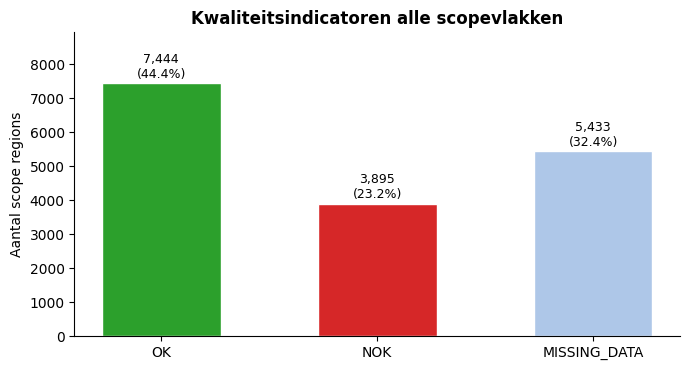

In [34]:
# OK: 7,444 train/test regions
# NOK: 2,484 (reliability) + 1,411 (insufficient timestamps) = 3,895
# MISSING_DATA: 5,433 (single timestamp — no prediction possible)
counts = {'OK': 7_444, 'NOK': 3_895, 'MISSING_DATA': 5_433}
total  = sum(counts.values())  # 16,772

fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(counts.keys(), counts.values(),
              color=['#2ca02c', '#d62728', '#aec7e8'], edgecolor='white', width=0.55)
for bar, (lbl, n) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.004,
            f'{n:,}\n({n/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Aantal scope regions')
ax.set_title('Kwaliteitsindicatoren alle scopevlakken', fontweight='bold')
ax.set_ylim(0, max(counts.values()) * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
# scope_quality loaded in cell above


In [36]:
scope_quality['estimate_reliability_height_model'].unique()

array(['OK', 'NOK', 'MISSING_DATA'], dtype=object)

## 1 — Target: v_test distribution

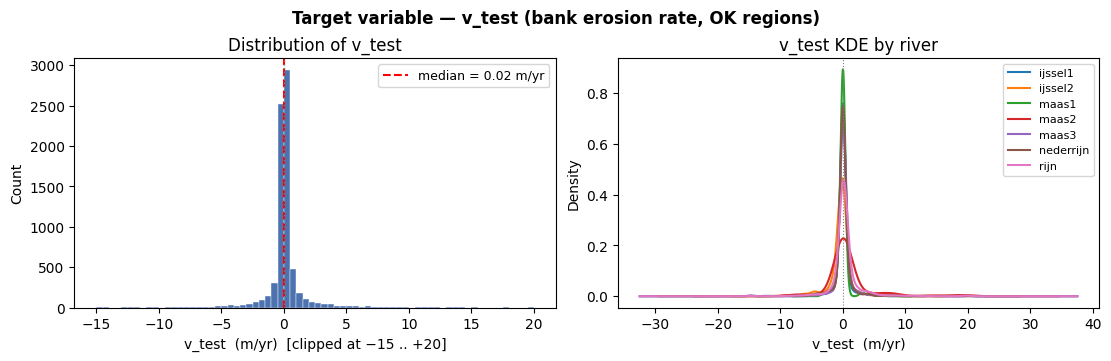

count    7444.000
mean        0.150
std         2.187
min       -38.896
25%        -0.111
50%         0.021
75%         0.223
max        34.273
Name: v_test, dtype: float64


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

ax = axes[0]
ax.hist(feat_ok['v_test'].clip(-15, 20), bins=70,
        color='#4c72b0', edgecolor='white', lw=0.3)
ax.axvline(feat_ok['v_test'].median(), color='red', lw=1.5, ls='--',
           label=f"median = {feat_ok['v_test'].median():.2f} m/yr")
ax.axvline(0, color='grey', lw=1, ls=':')
ax.set_xlabel('v_test  (m/yr)  [clipped at −15 .. +20]')
ax.set_ylabel('Count')
ax.set_title('Distribution of v_test')
ax.legend(fontsize=9)

ax = axes[1]
for river, grp in feat_ok.groupby('river')['v_test']:
    grp.clip(-15, 20).plot(kind='kde', ax=ax, label=river)
ax.set_xlabel('v_test  (m/yr)')
ax.set_title('v_test KDE by river')
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.legend(fontsize=8)

plt.suptitle('Target variable — v_test (bank erosion rate, OK regions)', fontweight='bold')
plt.show()
print(feat_ok['v_test'].describe().round(3))

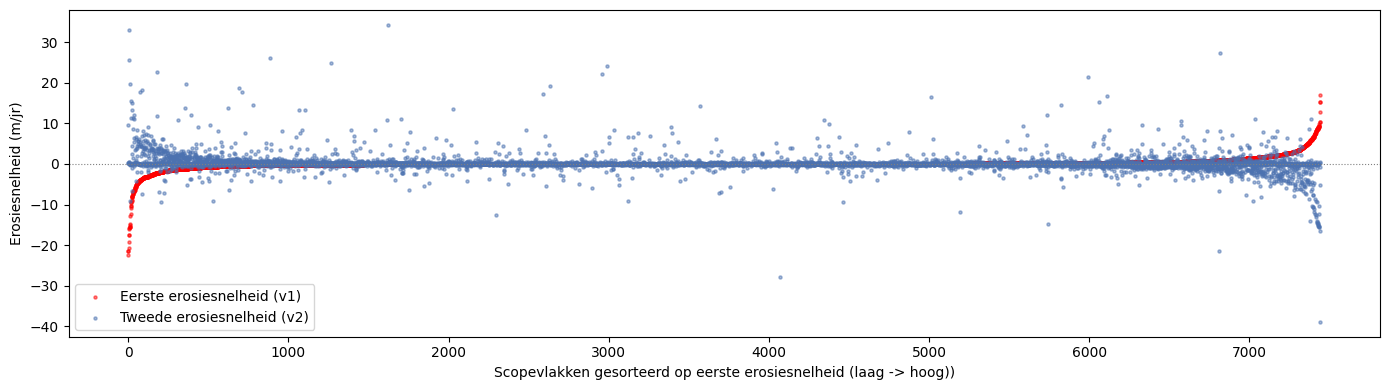

In [77]:
# v_train vs v_test sorted by v_train — reveals mean-reversion pattern
df = feat_ok[['v_train', 'v_test']].dropna().sort_values('v_train').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(df))
ax.scatter(x, df['v_train'], c='red',     s=5, alpha=0.5, label='Eerste erosiesnelheid (v1)')
ax.scatter(x, df['v_test'],  c='#4c72b0', s=5, alpha=0.5, label='Tweede erosiesnelheid (v2)')
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Scopevlakken gesorteerd op eerste erosiesnelheid (laag -> hoog))')
ax.set_ylabel('Erosiesnelheid (m/jr)')
ax.set_title('')
ax.legend()
plt.tight_layout()
plt.show()

## 2 — Erosion volume rate (erosion_vol_rate_t1)

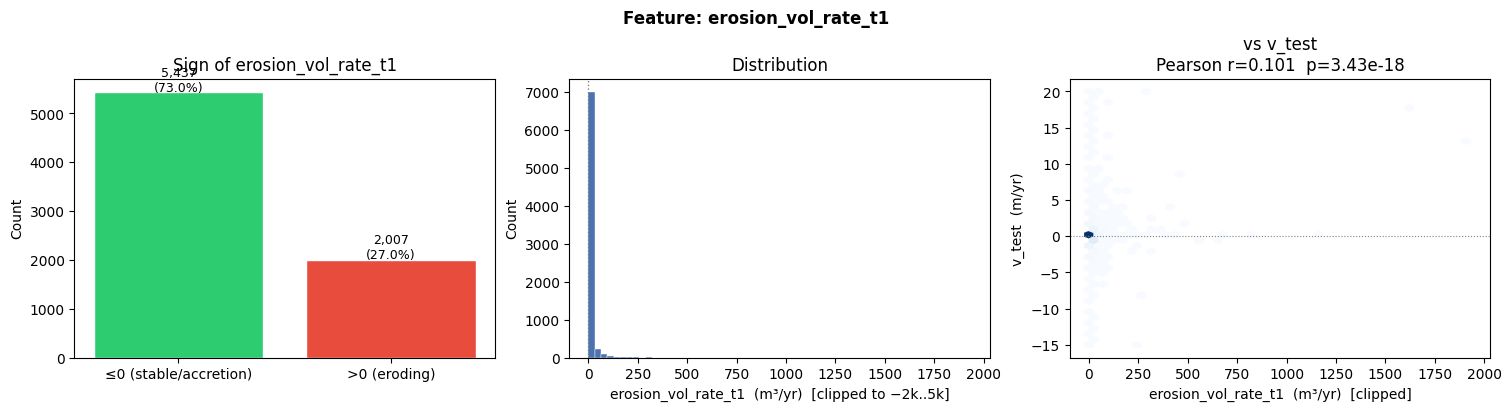

count    7444.00
mean        7.28
std        43.71
min         0.00
25%         0.00
50%         0.00
75%         0.37
max      1934.22
Name: erosion_vol_rate_t1, dtype: float64


In [39]:
vol_col = 'erosion_vol_rate_t1'
df_vol = feat_ok[[vol_col, 'v_test']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# Sign breakdown
ax = axes[0]
sign = pd.cut(feat_ok[vol_col].dropna(),
              bins=[-np.inf, 0, np.inf], labels=['≤0 (stable/accretion)', '>0 (eroding)'])
counts = sign.value_counts()
ax.bar(counts.index.astype(str), counts.values,
       color=['#2ecc71', '#e74c3c'], edgecolor='white')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 20, f'{val:,}\n({val/feat_ok[vol_col].notna().sum():.1%})',
            ha='center', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Sign of erosion_vol_rate_t1')

# Distribution (clipped)
ax = axes[1]
nz = feat_ok[vol_col].dropna()
ax.hist(nz.clip(-2000, 5000), bins=60, color='#4c72b0', edgecolor='white', lw=0.3)
ax.axvline(0, color='grey', lw=1, ls=':')
ax.set_xlabel('erosion_vol_rate_t1  (m³/yr)  [clipped to −2k..5k]')
ax.set_ylabel('Count')
ax.set_title('Distribution')

# Scatter vs v_test
ax = axes[2]
r, p = stats.pearsonr(df_vol[vol_col], df_vol['v_test'])
ax.hexbin(df_vol[vol_col].clip(-2000, 5000), df_vol['v_test'].clip(-15, 20),
          gridsize=40, cmap='Blues', mincnt=1, linewidths=0.2)
ax.set_xlabel('erosion_vol_rate_t1  (m³/yr)  [clipped]')
ax.set_ylabel('v_test  (m/yr)')
ax.set_title(f'vs v_test\nPearson r={r:.3f}  p={p:.2e}')
ax.axhline(0, color='grey', lw=0.8, ls=':')

plt.suptitle('Feature: erosion_vol_rate_t1', fontweight='bold')
plt.show()
print(feat_ok[vol_col].describe().round(2))

## 3 — Feature: v_train (historical erosion rate)

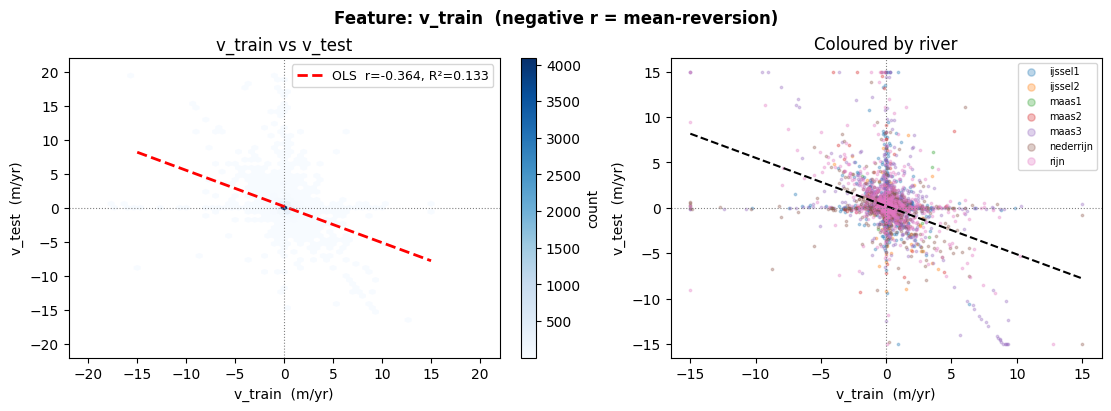

Pearson r = -0.3644   R² = 0.1328   p = 1.38e-232


In [40]:
df = feat_ok.dropna(subset=['v_train', 'v_test'])
slope, intercept, r, p, _ = stats.linregress(df['v_train'], df['v_test'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax = axes[0]
hb = ax.hexbin(df['v_train'], df['v_test'], gridsize=60, cmap='Blues',
               mincnt=1, linewidths=0.2, extent=(-20, 20, -20, 20))
x_ = np.linspace(-15, 15, 100)
ax.plot(x_, slope * x_ + intercept, 'r--', lw=2,
        label=f'OLS  r={r:.3f}, R²={r**2:.3f}')
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('v_train  (m/yr)')
ax.set_ylabel('v_test  (m/yr)')
ax.set_title('v_train vs v_test')
ax.legend(fontsize=9)
plt.colorbar(hb, ax=ax, label='count')

ax = axes[1]
for river, grp in df.groupby('river'):
    ax.scatter(grp['v_train'].clip(-15, 15), grp['v_test'].clip(-15, 15),
               s=3, alpha=0.3, label=river)
ax.plot(x_, slope * x_ + intercept, 'k--', lw=1.5)
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('v_train  (m/yr)')
ax.set_ylabel('v_test  (m/yr)')
ax.set_title('Coloured by river')
ax.legend(fontsize=7, markerscale=3)

plt.suptitle('Feature: v_train  (negative r = mean-reversion)', fontweight='bold')
plt.show()
print(f'Pearson r = {r:.4f}   R² = {r**2:.4f}   p = {p:.2e}')

## 4 — Feature: dist_t2 (absolute bank position)

dist_t2 vs v_test — per cluster:
  cluster    n  Pearson_r  Spearman_rho
  ijssel1 1810    -0.0648        0.0104
  ijssel2  287    -0.3534       -0.3616
    maas1  127     0.0116       -0.1528
    maas2  178    -0.1166       -0.0570
    maas3 2681    -0.2249       -0.0752
nederrijn 1198    -0.1369       -0.0732
     rijn 1163    -0.0179        0.0548


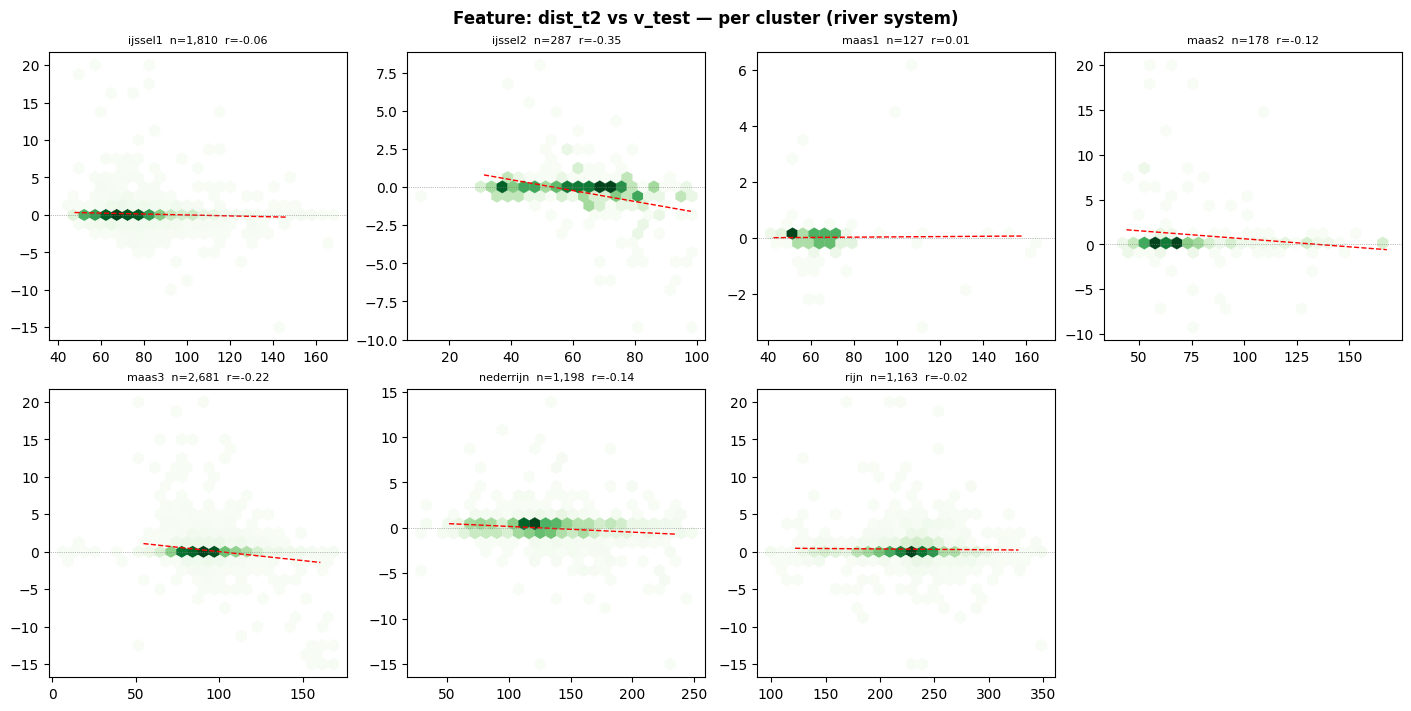

In [41]:
df = feat_ok.dropna(subset=['dist_t2', 'v_test', 'cluster'])
clusters = sorted(df['cluster'].unique())

results = []
for cl in clusters:
    sub = df[df['cluster'] == cl]
    if len(sub) < 10:
        continue
    r, p = stats.pearsonr(sub['dist_t2'], sub['v_test'])
    rho, _ = stats.spearmanr(sub['dist_t2'], sub['v_test'])
    results.append({'cluster': cl, 'n': len(sub), 'Pearson_r': round(r, 4), 'Spearman_rho': round(rho, 4)})

print('dist_t2 vs v_test — per cluster:')
print(pd.DataFrame(results).to_string(index=False))

n_cols = 4
n_rows = (len(clusters) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), constrained_layout=True)
axes_flat = np.array(axes).flatten()

for idx, cl in enumerate(clusters):
    ax = axes_flat[idx]
    sub = df[df['cluster'] == cl]
    if len(sub) < 10:
        ax.set_axis_off()
        continue
    ax.hexbin(sub['dist_t2'], sub['v_test'].clip(-15, 20),
              gridsize=25, cmap='Greens', mincnt=1, linewidths=0.2)
    sl, ic, r_cl, *_ = stats.linregress(sub['dist_t2'], sub['v_test'])
    x_ = np.linspace(sub['dist_t2'].quantile(0.01), sub['dist_t2'].quantile(0.99), 100)
    ax.plot(x_, sl * x_ + ic, 'r--', lw=1)
    ax.set_title(f'{cl}  n={len(sub):,}  r={r_cl:.2f}', fontsize=8)
    ax.axhline(0, color='grey', lw=0.5, ls=':')

for ax in axes_flat[len(clusters):]:
    ax.set_axis_off()

plt.suptitle('Feature: dist_t2 vs v_test — per cluster (river system)', fontweight='bold')
plt.show()

## 5 — Feature: is_nvo (nature-friendly bank)

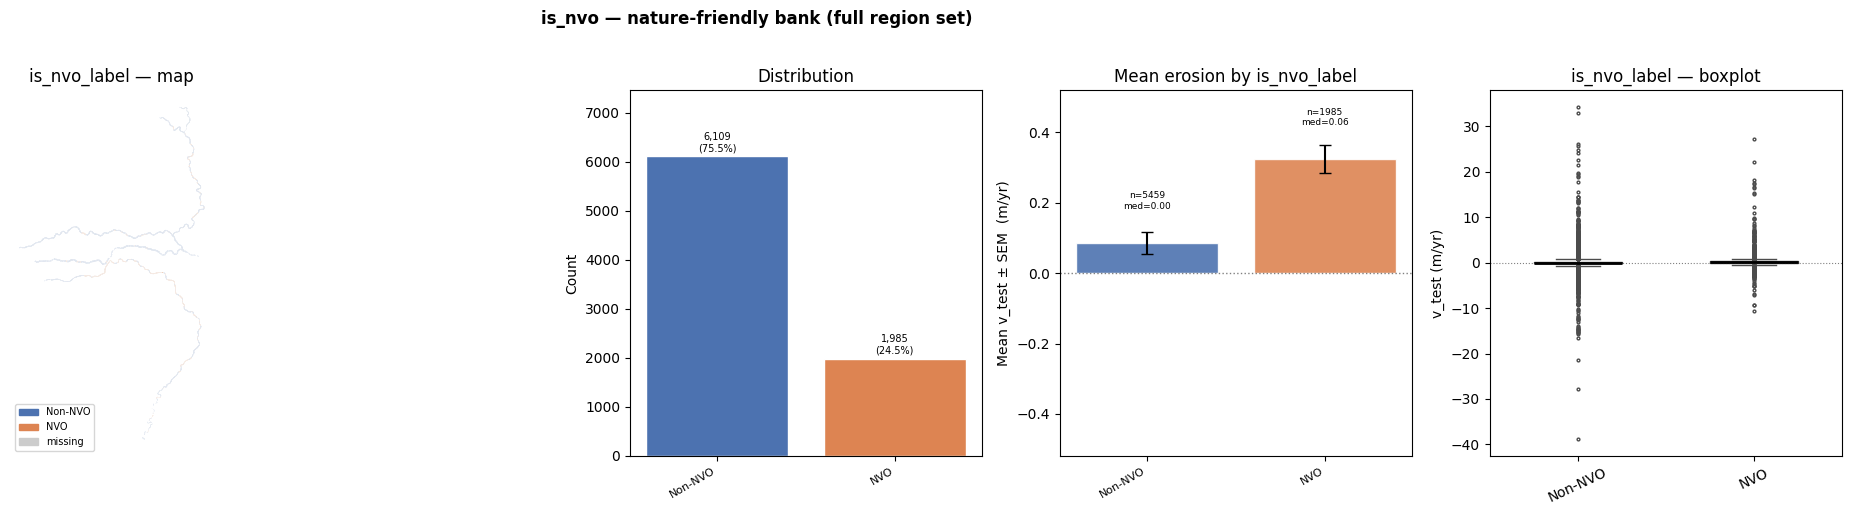

Non-NVO  mean=0.086  median=0.000  n=5,459
NVO      mean=0.325  median=0.056  n=1,985
Mann-Whitney p=7.6575e-22   Cohen's d=0.115


In [42]:
# Map bool to string label for all plots
feat_all_nvo = feat_all.copy()
feat_all_nvo['is_nvo_label'] = feat_all_nvo['is_nvo'].map({False: 'Non-NVO', True: 'NVO'})

feat_ok_nvo = feat_ok.copy()
feat_ok_nvo['is_nvo_label'] = feat_ok_nvo['is_nvo'].map({False: 'Non-NVO', True: 'NVO'})

feature_overview(
    scope_full, feat_all_nvo,
    col='is_nvo_label',
    title='is_nvo — nature-friendly bank (full region set)',
    feat_ok_df=feat_ok_nvo,
    order=['Non-NVO', 'NVO'],
    palette=['#4c72b0', '#dd8452'],
)

nvo     = feat_ok.loc[ feat_ok['is_nvo'], 'v_test'].dropna()
non_nvo = feat_ok.loc[~feat_ok['is_nvo'], 'v_test'].dropna()
u, p = stats.mannwhitneyu(nvo, non_nvo, alternative='two-sided')
d = (nvo.mean() - non_nvo.mean()) / np.sqrt((nvo.std()**2 + non_nvo.std()**2) / 2)
print(f'Non-NVO  mean={non_nvo.mean():.3f}  median={non_nvo.median():.3f}  n={len(non_nvo):,}')
print(f'NVO      mean={nvo.mean():.3f}  median={nvo.median():.3f}  n={len(nvo):,}')
print(f'Mann-Whitney p={p:.4e}   Cohen\'s d={d:.3f}')

## 6 — Feature: river segment

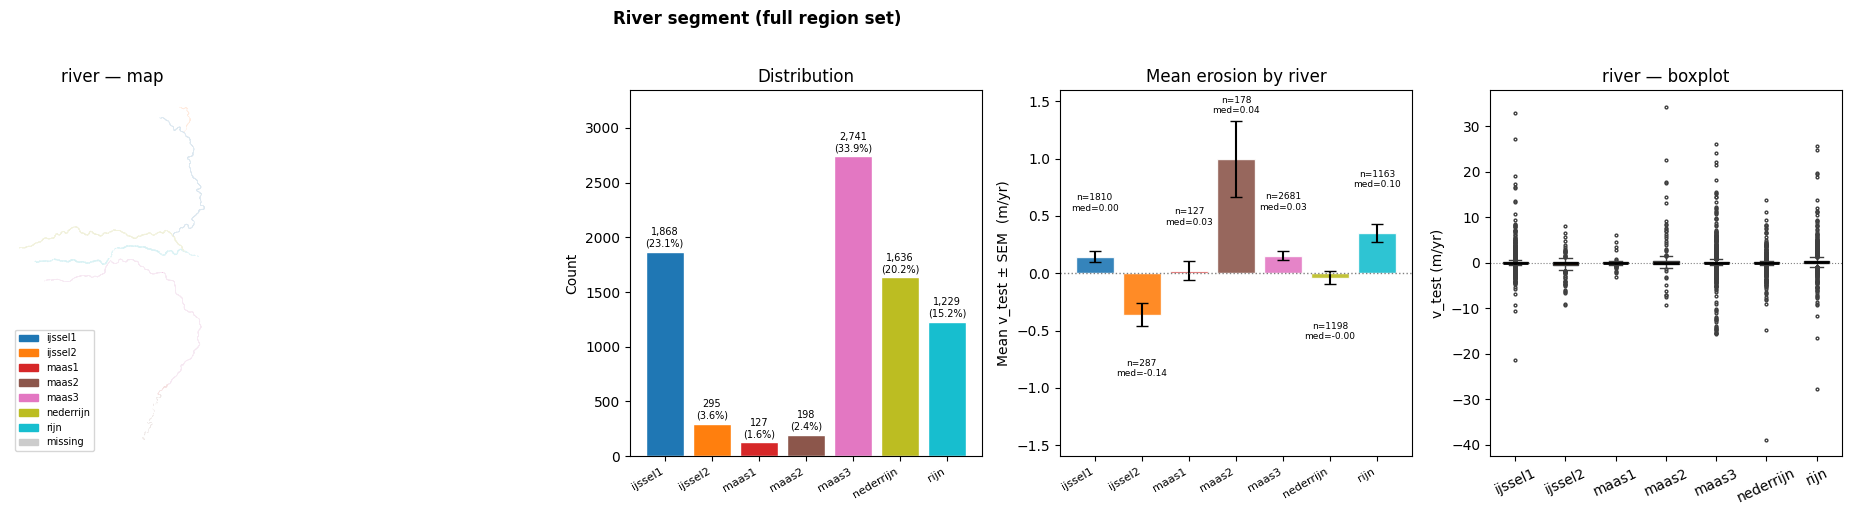

v_test stats per river (OK regions):
            mean  median    std  count
river                                 
ijssel1    0.145   0.000  1.913   1810
ijssel2   -0.361  -0.139  1.743    287
maas1      0.022   0.026  0.938    127
maas2      0.997   0.045  4.456    178
maas3      0.154   0.028  2.133   2681
nederrijn -0.039  -0.000  1.887   1198
rijn       0.352   0.104  2.577   1163


In [43]:
rivers = sorted(feat_all['river'].dropna().unique())
feature_overview(
    scope_full, feat_all,
    col='river',
    title='River segment (full region set)',
    feat_ok_df=feat_ok,
    order=rivers,
    cmap='tab10',
)

print('v_test stats per river (OK regions):')
print(feat_ok.groupby('river')['v_test']
      .agg(['mean', 'median', 'std', 'count']).round(3))

## 7 — Feature: vegetation class

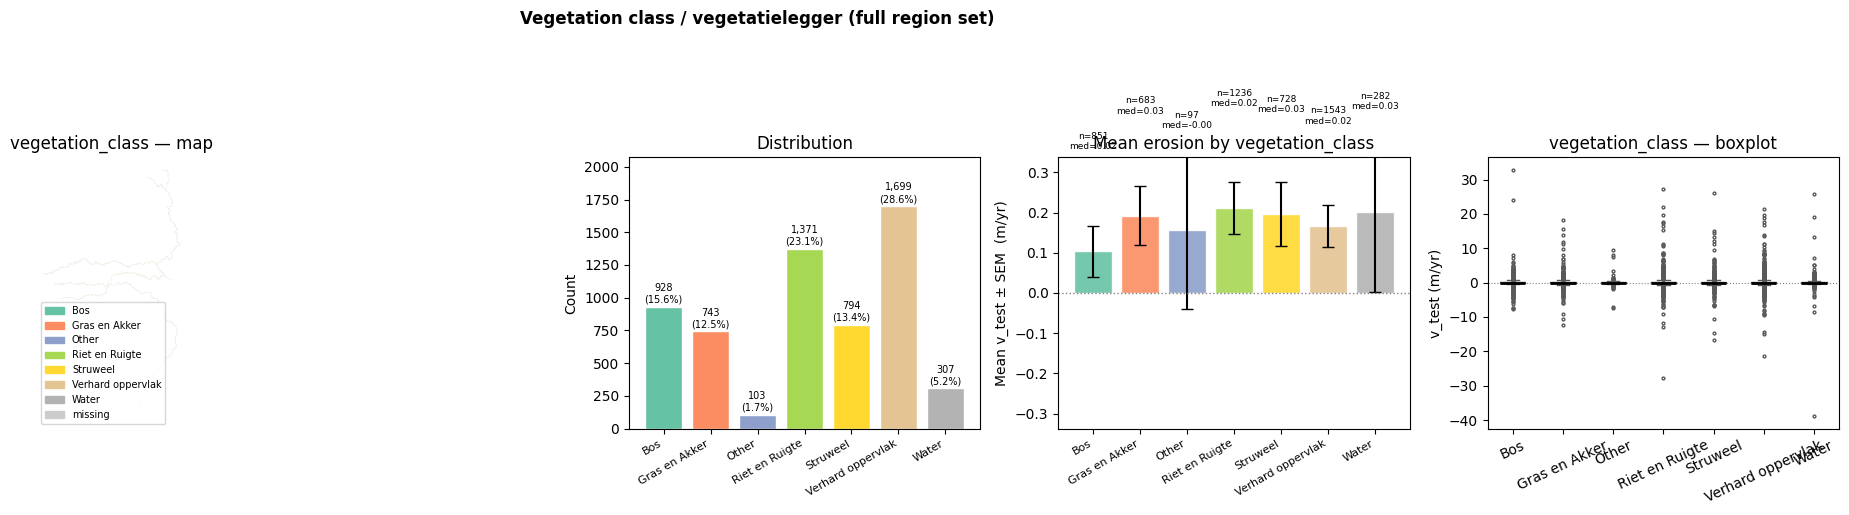

Coverage:
  Full set : 5,945 / 8,094  (73.4%)
  OK only  : 5,420 / 7,444

Distribution (full):
vegetation_class
Verhard oppervlak    1699
Riet en Ruigte       1371
Bos                   928
Struweel              794
Gras en Akker         743
Water                 307
Other                 103


In [44]:
veg_order = sorted(feat_all['vegetation_class'].dropna().unique())
feature_overview(
    scope_full, feat_all,
    col='vegetation_class',
    title='Vegetation class / vegetatielegger (full region set)',
    feat_ok_df=feat_ok,
    order=veg_order,
    cmap='Set2',
)

print('Coverage:')
print(f'  Full set : {feat_all["vegetation_class"].notna().sum():,} / {len(feat_all):,}  '
      f'({feat_all["vegetation_class"].notna().mean():.1%})')
print(f'  OK only  : {feat_ok["vegetation_class"].notna().sum():,} / {len(feat_ok):,}')
print('\nDistribution (full):')
print(feat_all['vegetation_class'].value_counts().to_string())

## 8 — Feature: land use (BRP Gewas)

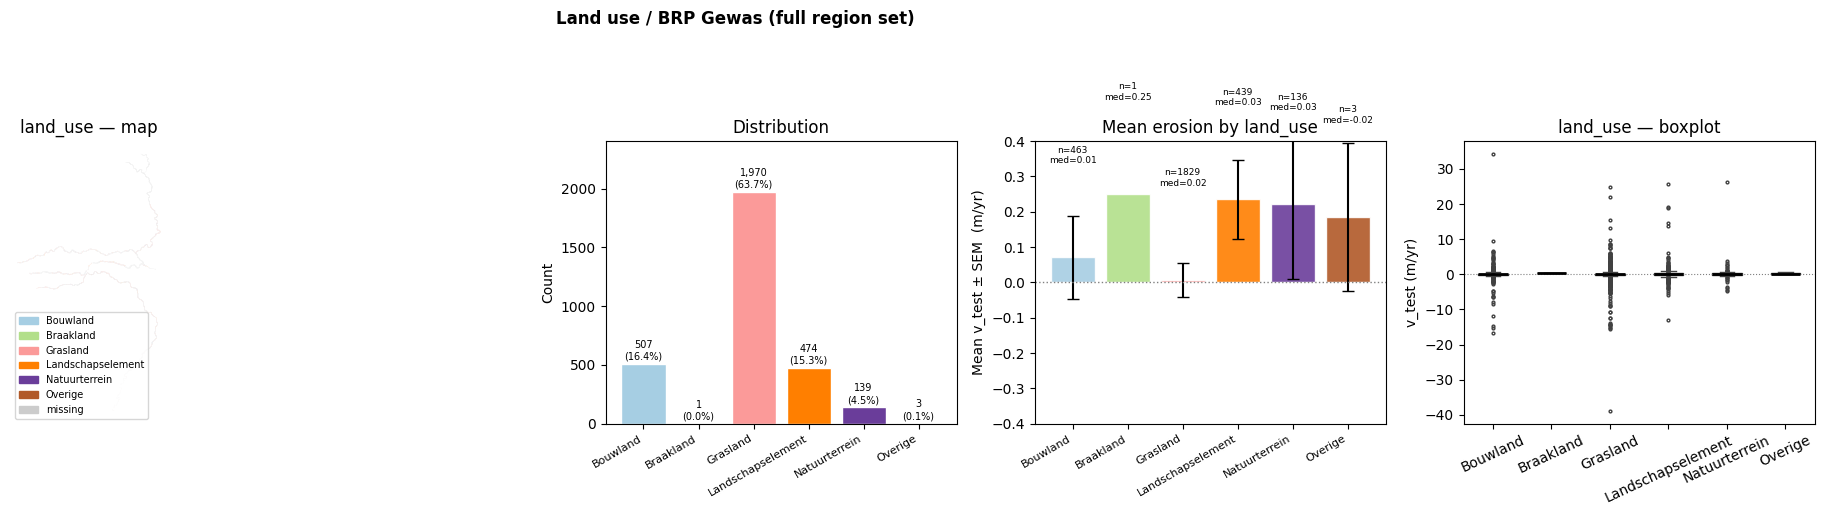

Distribution (full):
land_use
Grasland             1970
Bouwland              507
Landschapselement     474
Natuurterrein         139
Overige                 3
Braakland               1


In [45]:
lu_order = sorted(feat_all['land_use'].dropna().unique())
feature_overview(
    scope_full, feat_all,
    col='land_use',
    title='Land use / BRP Gewas (full region set)',
    feat_ok_df=feat_ok,
    order=lu_order,
    cmap='Paired',
)

print('Distribution (full):')
print(feat_all['land_use'].value_counts().to_string())

## 9 — Feature: bend exposure / curvature

**Hypothesis:** Banks on the outer bend of a meander erode faster than those on the inner bend or straight sections.  
Two scales are available: `bend_exposure_n5` (5-segment window) and `bend_exposure_n8` (8-segment window).  
Positive exposure = outer bend; negative = inner bend; near-zero = straight.

Bend exposure — Pearson / Spearman r with v_test (OK regions):

Feature                System           n   Pearson r  Spearman ρ
────────────────────────────────────────────────────────────────────
bend_exposure_n5       Maas          2986     +0.0260     +0.0276
bend_exposure_n5       Rijntakken    4458     +0.0072     +0.0122
bend_exposure_n8       Maas          2986     +0.0181     +0.0243
bend_exposure_n8       Rijntakken    4458     +0.0046     +0.0054


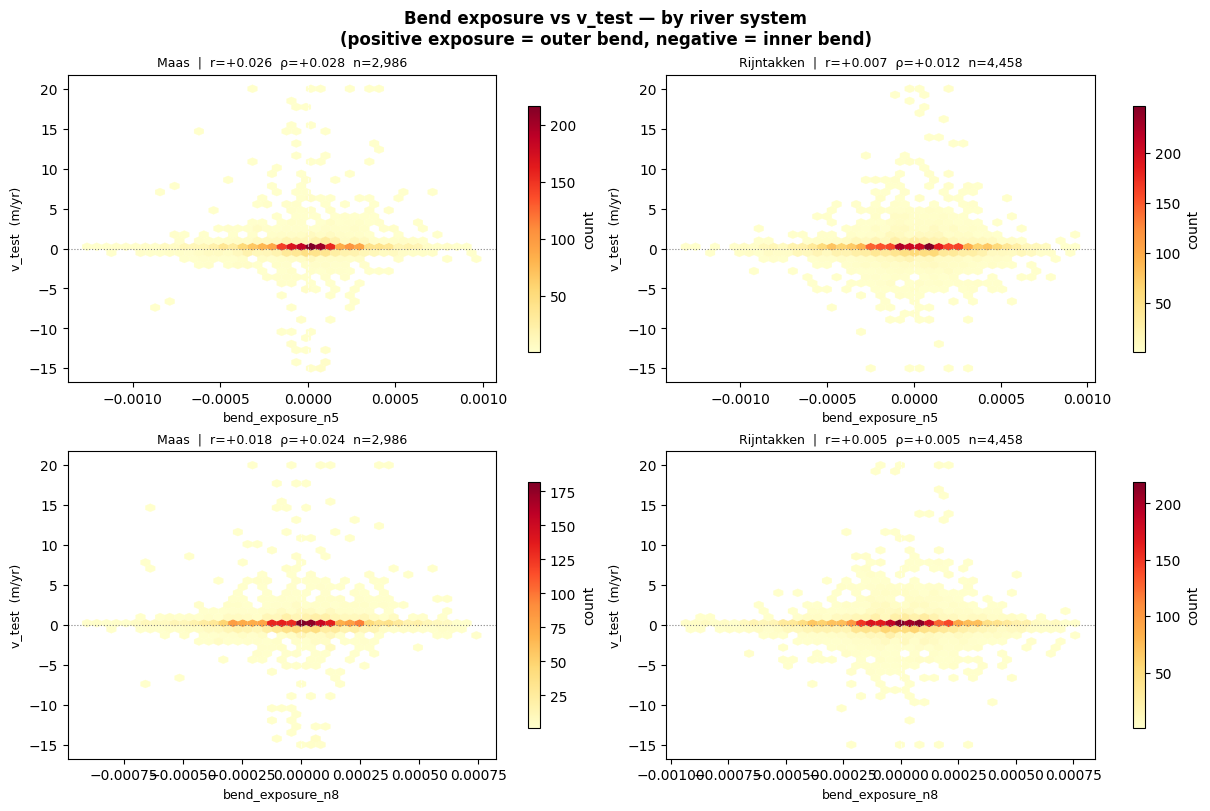

In [46]:
bend_cols = ['bend_exposure_n5', 'bend_exposure_n8']
maas_mask = feat_ok['river'].str.startswith('maas')
systems   = {'Maas': maas_mask, 'Rijntakken': ~maas_mask}
sys_colors = {'Maas': '#e74c3c', 'Rijntakken': '#3498db'}

# ── Correlations table ────────────────────────────────────────────────────────
print('Bend exposure — Pearson / Spearman r with v_test (OK regions):\n')
print(f'{"Feature":<22} {"System":<12} {"n":>5}  {"Pearson r":>10}  {"Spearman ρ":>10}')
print('─' * 68)
for col in bend_cols:
    for sys_name, mask in systems.items():
        sub = feat_ok.loc[mask].dropna(subset=[col, 'v_test'])
        if len(sub) < 10:
            continue
        r,   _ = stats.pearsonr(sub[col],  sub['v_test'])
        rho, _ = stats.spearmanr(sub[col], sub['v_test'])
        print(f'{col:<22} {sys_name:<12} {len(sub):>5}  {r:>+10.4f}  {rho:>+10.4f}')

# ── Hexbin: each bend col vs v_test, split by river system ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for row_idx, col in enumerate(bend_cols):
    for col_idx, (sys_name, mask) in enumerate(systems.items()):
        ax = axes[row_idx][col_idx]
        sub = feat_ok.loc[mask].dropna(subset=[col, 'v_test'])
        hb = ax.hexbin(sub[col], sub['v_test'].clip(-15, 20),
                       gridsize=40, cmap='YlOrRd', mincnt=1, linewidths=0.2)
        r, _ = stats.pearsonr(sub[col], sub['v_test'])
        rho, _ = stats.spearmanr(sub[col], sub['v_test'])

        ax.axhline(0,  color='grey',  lw=0.8, ls=':')
        ax.axvline(0,  color='white', lw=0.8, ls='--', alpha=0.6)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('v_test  (m/yr)', fontsize=9)
        ax.set_title(f'{sys_name}  |  r={r:+.3f}  ρ={rho:+.3f}  n={len(sub):,}', fontsize=9)
        plt.colorbar(hb, ax=ax, label='count', shrink=0.8)

plt.suptitle('Bend exposure vs v_test — by river system\n'
             '(positive exposure = outer bend, negative = inner bend)', fontweight='bold')
plt.show()

Scope regions per bend zone:


bend_zone,inner,straight,outer
system,,,
Maas,157,2729,100
Rijntakken,299,3975,184


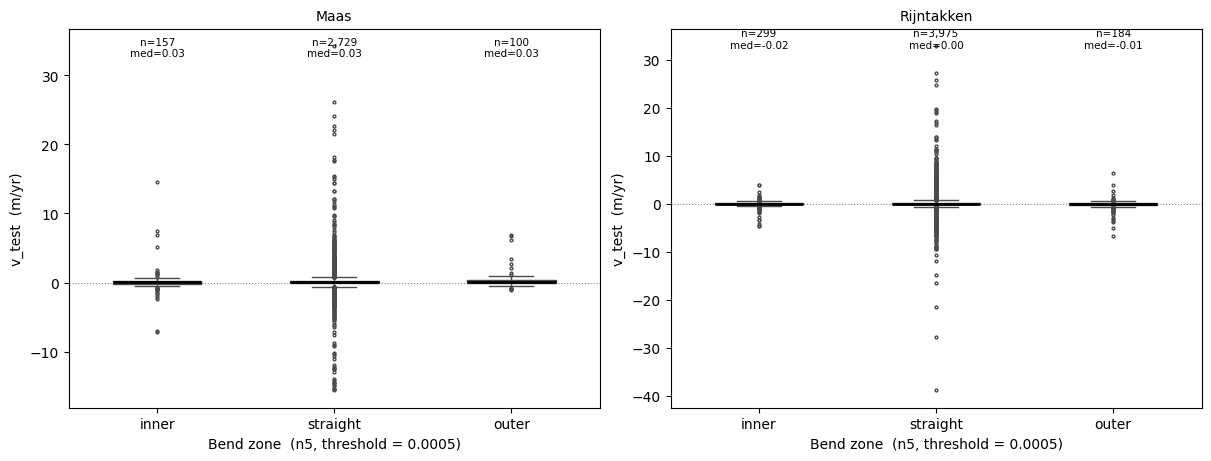

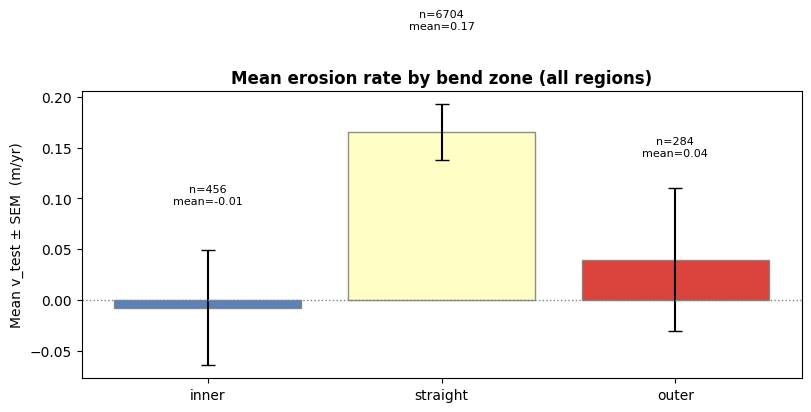

<Figure size 640x480 with 0 Axes>

In [75]:
# ── Bend zone classification: inner / straight / outer ───────────────────────
THRESH = 0.0005   # 1/m boundary between straight and curved
feat_ok = feat_ok.copy()
feat_ok['bend_zone'] = pd.cut(
    feat_ok['bend_exposure_n5'],
    bins=[-np.inf, -THRESH, THRESH, np.inf],
    labels=['inner', 'straight', 'outer']
)

zone_counts = (
    feat_ok.assign(system=np.where(maas_mask, 'Maas', 'Rijntakken'))
    .groupby(['system', 'bend_zone'], observed=True)
    .size().unstack(fill_value=0)
)
print('Scope regions per bend zone:')
display(zone_counts)

palette_zone = {'inner': '#4575b4', 'straight': '#ffffbf', 'outer': '#d73027'}
order_zone   = ['inner', 'straight', 'outer']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for ax, (sys_name, mask) in zip(axes, systems.items()):
    sub = feat_ok.loc[mask].dropna(subset=['bend_zone', 'v_test'])
    sns.boxplot(data=sub, x='bend_zone', y='v_test', order=order_zone,
                palette=palette_zone, width=0.5, fliersize=2,
                medianprops=dict(color='black', lw=2), ax=ax)
    # Annotate n + median per zone
    for xi, zone in enumerate(order_zone):
        grp = sub.loc[sub['bend_zone'] == zone, 'v_test']
        ax.text(xi, ax.get_ylim()[1] * 0.89,
                f'n={len(grp):,}\nmed={grp.median():.2f}',
                ha='center', fontsize=7.5)
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(f'{sys_name}', fontsize=10)
    ax.set_xlabel('Bend zone  (n5, threshold = 0.0005)')
    ax.set_ylabel('v_test  (m/yr)')

# Mean erosion bar next to boxplot
fig2, ax2 = plt.subplots(figsize=(8, 4), constrained_layout=True)
all_zones = feat_ok.dropna(subset=['bend_zone', 'v_test'])
zone_stats = (all_zones.groupby(['bend_zone', 'river'.replace('river', 'river')], observed=True)['v_test']
              .agg(mean='mean', sem=lambda x: x.sem(), n='count')
              .reset_index()
              .rename(columns={'river': 'river'}))
zone_mean = (all_zones.groupby('bend_zone', observed=True)['v_test']
             .agg(mean='mean', sem=lambda x: x.sem(), n='count')
             .reindex(order_zone))
x_pos = np.arange(len(order_zone))
ax2.bar(x_pos, zone_mean['mean'], yerr=zone_mean['sem'], capsize=5,
        color=[palette_zone[z] for z in order_zone], edgecolor='grey', alpha=0.9)
for xi, zone in enumerate(order_zone):
    row = zone_mean.loc[zone]
    offset = zone_mean['sem'].max() + 0.03
    ax2.text(xi, row['mean'] + offset, f'n={int(row["n"])}\nmean={row["mean"]:.2f}',
             ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(order_zone)
ax2.axhline(0, color='grey', lw=1, ls=':')
ax2.set_ylabel('Mean v_test ± SEM  (m/yr)')
ax2.set_title('Mean erosion rate by bend zone (all regions)', fontweight='bold')
plt.show()

plt.suptitle('Bend zone (n5) vs v_test — by river system', fontweight='bold')
plt.tight_layout()
plt.show()

Counts (bend_zone × NVO):


nvo_label,NVO,niet NVO
bend_zone,,
inner,94,362
straight,1845,4859
outer,46,238



% NVO per bend zone:


nvo_label,NVO,niet NVO
bend_zone,,
inner,20.6,79.4
straight,27.5,72.5
outer,16.2,83.8


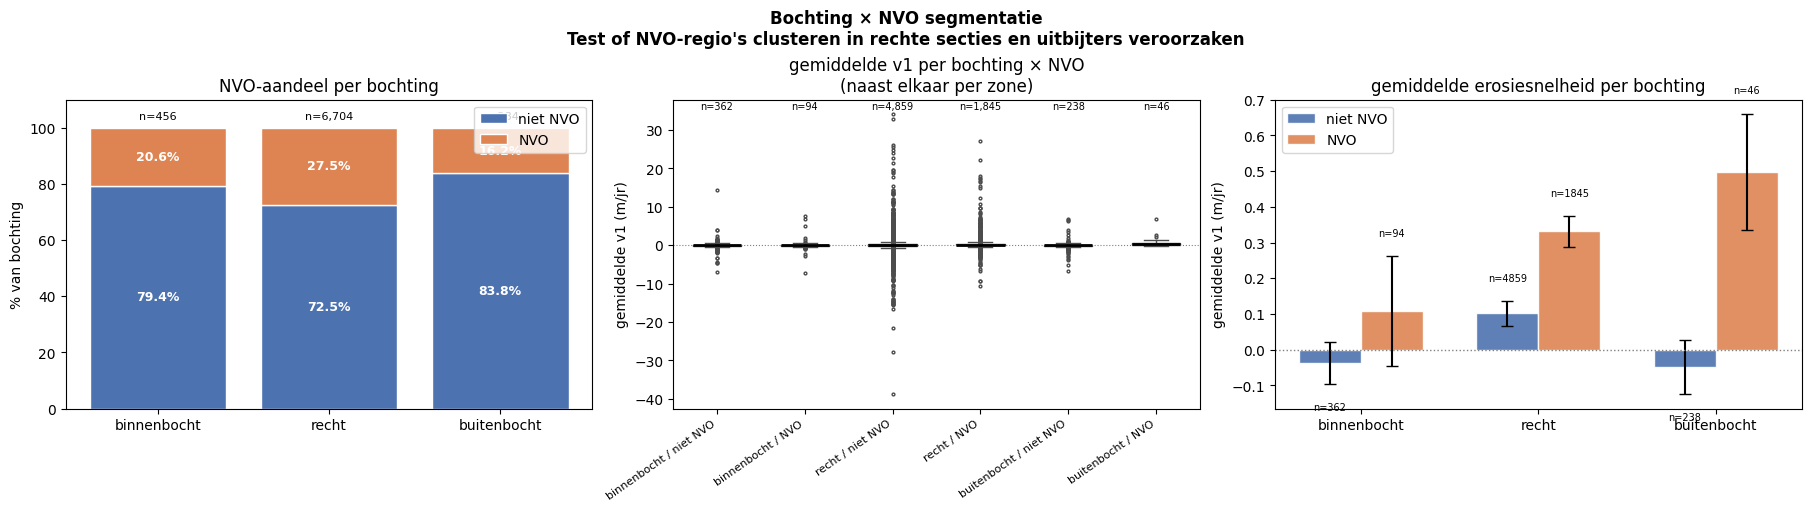

In [78]:
# ── NVO segmentation per bend zone ───────────────────────────────────────────
# Hypothesis: straight sections are the only ones containing NVO regions,
# and thus the source of extreme v_test outliers in that bucket.

df_bz = feat_ok.dropna(subset=['bend_zone', 'v_test']).copy()
df_bz['nvo_label'] = df_bz['is_nvo'].map({True: 'NVO', False: 'niet NVO'})
order_zone = ['inner', 'straight', 'outer']
zone_display = {'inner': 'binnenbocht', 'straight': 'recht', 'outer': 'buitenbocht'}
order_zone_nl = [zone_display[z] for z in order_zone]

# ── Cross-tab: counts and % ───────────────────────────────────────────────────
xtab = pd.crosstab(df_bz['bend_zone'], df_bz['nvo_label'])
xtab = xtab.reindex(order_zone)
xtab_pct = xtab.div(xtab.sum(axis=1), axis=0) * 100
print('Counts (bend_zone × NVO):')
display(xtab)
print('\n% NVO per bend zone:')
display(xtab_pct.round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Panel 1: stacked % bar — NVO share per bend zone
ax = axes[0]
bottom = np.zeros(len(order_zone))
colors_nvo = {'niet NVO': '#4c72b0', 'NVO': '#dd8452'}
for label in ['niet NVO', 'NVO']:
    vals = xtab_pct[label].values
    bars = ax.bar(order_zone_nl, vals, bottom=bottom,
                  color=colors_nvo[label], label=label, edgecolor='white')
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax.text(xi, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals
ax.set_ylim(0, 110)
ax.set_ylabel('% van bochting')
ax.set_title('NVO-aandeel per bochting')
ax.legend(loc='upper right')
# Annotate total n per zone
for xi, zone in enumerate(order_zone):
    ax.text(xi, 103, f'n={xtab.loc[zone].sum():,}', ha='center', fontsize=8)

# Panel 2: boxplot v_test per bend_zone × NVO (side by side within each zone)
ax = axes[1]
zone_nvo_order = [(z, n) for z in order_zone for n in ['niet NVO', 'NVO']]
df_bz['zone_nvo'] = df_bz['bend_zone'].map(zone_display).astype(str) + ' / ' + df_bz['nvo_label'].astype(str)
combined_order = [f'{zone_display[z]} / {n}' for z, n in zone_nvo_order]
combined_colors = [colors_nvo[n] for _, n in zone_nvo_order]

sns.boxplot(data=df_bz, x='zone_nvo', y='v_test', order=combined_order,
            palette={k: v for k, v in zip(combined_order, combined_colors)},
            width=0.55, fliersize=2, medianprops=dict(color='black', lw=2), ax=ax)
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xticklabels(combined_order, rotation=35, ha='right', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('gemiddelde v1 (m/jr)')
ax.set_title('gemiddelde v1 per bochting × NVO\n(naast elkaar per zone)')
# Annotate n per group
for xi, key in enumerate(combined_order):
    n = (df_bz['zone_nvo'] == key).sum()
    ax.text(xi, ax.get_ylim()[1] * 0.93, f'n={n:,}', ha='center', fontsize=7)

# Panel 3: mean ± SEM per zone × NVO (cleaner summary)
ax = axes[2]
zone_nvo_stats = (
    df_bz.groupby(['bend_zone', 'nvo_label'], observed=True)['v_test']
    .agg(mean='mean', sem=lambda x: x.sem(), n='count', median='median')
    .reset_index()
)
x_ticks = np.arange(len(order_zone))
width = 0.35
for i, (nvo_label, color) in enumerate(colors_nvo.items()):
    sub = zone_nvo_stats[zone_nvo_stats['nvo_label'] == nvo_label].set_index('bend_zone').reindex(order_zone)
    offset = (i - 0.5) * width
    bars = ax.bar(x_ticks + offset, sub['mean'], width=width,
                  yerr=sub['sem'], capsize=4,
                  color=color, edgecolor='white', alpha=0.9, label=nvo_label)
    for xi, (_, row) in enumerate(sub.iterrows()):
        if not np.isnan(row['mean']):
            sign = 1 if row['mean'] >= 0 else -1
            ax.text(xi + offset,
                    row['mean'] + sign * (row['sem'] + 0.05),
                    f'n={int(row["n"])}',
                    ha='center', va='bottom' if sign > 0 else 'top', fontsize=7)
ax.set_xticks(x_ticks)
ax.set_xticklabels(order_zone_nl)
ax.axhline(0, color='grey', lw=1, ls=':')
ax.set_ylabel('gemiddelde v1 (m/jr)')
ax.set_title('gemiddelde erosiesnelheid per bochting')
ax.legend()

plt.suptitle('Bochting × NVO segmentatie\n'
             'Test of NVO-regio\'s clusteren in rechte secties en uitbijters veroorzaken',
             fontweight='bold')
plt.show()

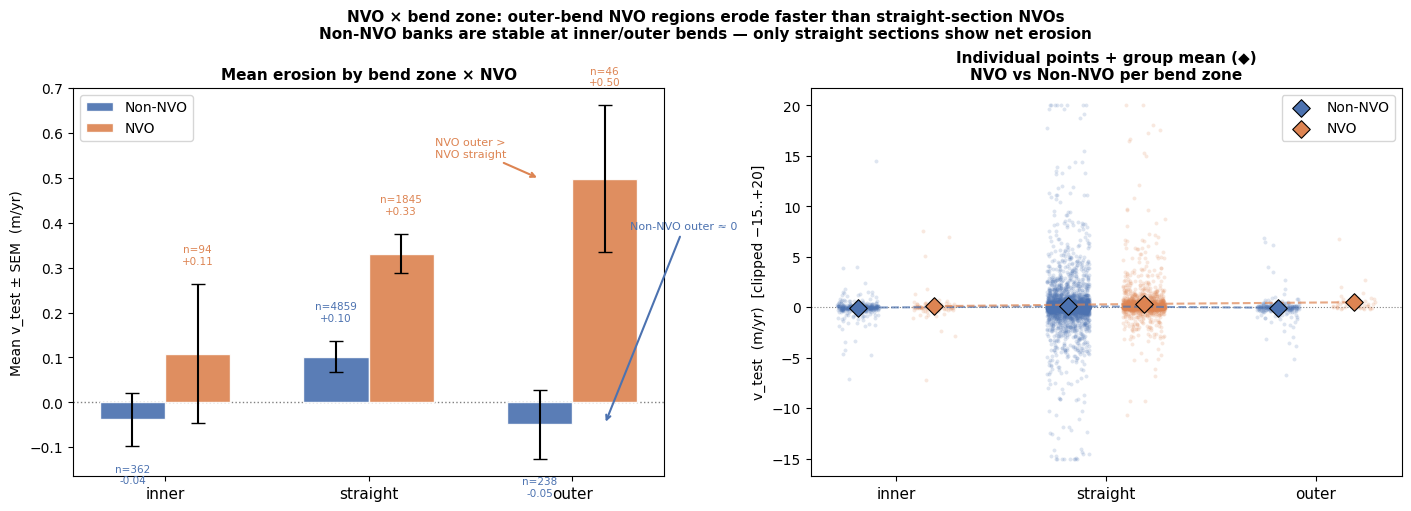

In [49]:
# ── Key finding: NVO × bend zone erosion pattern ─────────────────────────────
# Non-NVO: erosion only in straight sections — inner/outer bends are stable.
# NVO:     outer bends erode MORE than straight — exposure amplifies erosion.

df_bz = feat_ok.dropna(subset=['bend_zone', 'v_test']).copy()
df_bz['nvo_label'] = df_bz['is_nvo'].map({True: 'NVO', False: 'Non-NVO'})

order_zone   = ['inner', 'straight', 'outer']
colors_nvo   = {'Non-NVO': '#4c72b0', 'NVO': '#dd8452'}
width        = 0.32

stats_all = (
    df_bz.groupby(['bend_zone', 'nvo_label'], observed=True)['v_test']
    .agg(mean='mean', sem=lambda x: x.sem(), n='count', median='median')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# ── Panel 1: grouped bar — mean ± SEM ─────────────────────────────────────────
ax = axes[0]
x = np.arange(len(order_zone))

for i, (label, color) in enumerate(colors_nvo.items()):
    sub = (stats_all[stats_all['nvo_label'] == label]
           .set_index('bend_zone').reindex(order_zone))
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, sub['mean'], width=width,
                  yerr=sub['sem'], capsize=5,
                  color=color, edgecolor='white', alpha=0.92, label=label)
    for xi, (zone, row) in enumerate(sub.iterrows()):
        if np.isnan(row['mean']):
            continue
        sign   = 1 if row['mean'] >= 0 else -1
        y_text = row['mean'] + sign * (row['sem'] + 0.04)
        ax.text(xi + offset, y_text,
                f'n={int(row["n"])}\n{row["mean"]:+.2f}',
                ha='center', va='bottom' if sign > 0 else 'top',
                fontsize=7.5, color=color)

ax.axhline(0, color='grey', lw=1, ls=':', zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(order_zone, fontsize=11)
ax.set_ylabel('Mean v_test ± SEM  (m/yr)', fontsize=10)
ax.set_title('Mean erosion by bend zone × NVO', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

# Annotation arrows highlighting the key contrast
ymax = ax.get_ylim()[1]
ax.annotate('NVO outer >\nNVO straight',
            xy=(2 - 0.5 * width, stats_all.query("bend_zone=='outer' and nvo_label=='NVO'")['mean'].values[0]),
            xytext=(1.5, ymax * 0.78),
            arrowprops=dict(arrowstyle='->', color='#dd8452', lw=1.5),
            fontsize=8, color='#dd8452', ha='center')
ax.annotate('Non-NVO outer ≈ 0',
            xy=(2 + 0.5 * width, stats_all.query("bend_zone=='outer' and nvo_label=='Non-NVO'")['mean'].values[0]),
            xytext=(2.55, ymax * 0.55),
            arrowprops=dict(arrowstyle='->', color='#4c72b0', lw=1.5),
            fontsize=8, color='#4c72b0', ha='center')

# ── Panel 2: strip + mean marker — shows individual points + outlier structure
ax = axes[1]
x_jitter_seed = np.random.default_rng(42)
zone_x = {'inner': 0, 'straight': 1, 'outer': 2}

for label, color in colors_nvo.items():
    sub = df_bz[df_bz['nvo_label'] == label]
    for zone in order_zone:
        pts = sub.loc[sub['bend_zone'] == zone, 'v_test'].clip(-15, 20)
        offset = -0.18 if label == 'Non-NVO' else 0.18
        jitter = x_jitter_seed.uniform(-0.10, 0.10, len(pts))
        ax.scatter(zone_x[zone] + offset + jitter, pts,
                   color=color, alpha=0.18, s=8, linewidths=0)
    # Mean marker per zone
    means = (sub.groupby('bend_zone', observed=True)['v_test']
               .mean().reindex(order_zone))
    xs = [zone_x[z] + (-0.18 if label == 'Non-NVO' else 0.18) for z in order_zone]
    ax.scatter(xs, means.values, color=color, s=80, zorder=5,
               edgecolor='black', linewidths=0.8, marker='D', label=label)
    ax.plot(xs, means.values, color=color, lw=1.5, ls='--', alpha=0.7, zorder=4)

ax.axhline(0, color='grey', lw=0.8, ls=':', zorder=0)
ax.set_xticks(list(zone_x.values()))
ax.set_xticklabels(order_zone, fontsize=11)
ax.set_ylabel('v_test  (m/yr)  [clipped −15..+20]', fontsize=10)
ax.set_title('Individual points + group mean (◆)\nNVO vs Non-NVO per bend zone',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle(
    'NVO × bend zone: outer-bend NVO regions erode faster than straight-section NVOs\n'
    'Non-NVO banks are stable at inner/outer bends — only straight sections show net erosion',
    fontweight='bold', fontsize=11
)
plt.show()

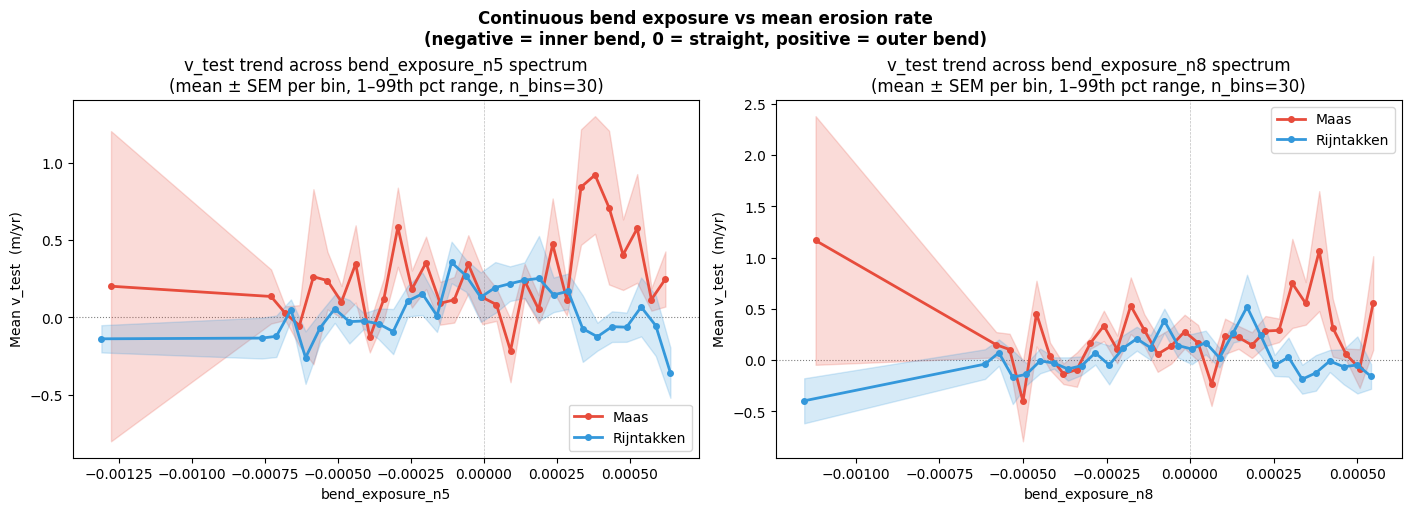

In [50]:
# ── Continuous: mean v_test per quantile bin of bend_exposure ────────────────
# Shows the actual trend across the spectrum instead of 3 coarse categories.
N_BINS = 30

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, col in zip(axes, ['bend_exposure_n5', 'bend_exposure_n8']):
    ax.axhline(0, color='grey', lw=0.8, ls=':', zorder=1)
    ax.axvline(0, color='grey', lw=0.5, ls='--', alpha=0.5, zorder=1)

    for sys_name, mask in systems.items():
        sub = feat_ok.loc[mask].dropna(subset=[col, 'v_test']).copy()

        # Equal-width bins clipped to the 1–99th percentile range to avoid sparse tails
        lo, hi = sub[col].quantile(0.01), sub[col].quantile(0.99)
        edges = np.linspace(lo, hi, N_BINS + 1)
        sub['_bin'] = pd.cut(sub[col], bins=edges, include_lowest=True)
        binned = (
            sub.groupby('_bin', observed=True)['v_test']
            .agg(mean='mean', sem=lambda x: x.sem(), n='count')
        )
        # Use bin midpoints on x-axis
        bin_mids = np.array([(iv.left + iv.right) / 2 for iv in binned.index])
        mask_ok  = binned['n'] >= 5          # only bins with enough data

        color = sys_colors[sys_name]
        ax.fill_between(
            bin_mids[mask_ok],
            (binned['mean'] - binned['sem'])[mask_ok],
            (binned['mean'] + binned['sem'])[mask_ok],
            color=color, alpha=0.20
        )
        ax.plot(bin_mids[mask_ok], binned['mean'][mask_ok],
                color=color, lw=2, label=sys_name, marker='o', ms=4, zorder=3)

    ax.set_xlabel(col)
    ax.set_ylabel('Mean v_test  (m/yr)')
    ax.set_title(f'v_test trend across {col} spectrum\n'
                 f'(mean ± SEM per bin, 1–99th pct range, n_bins={N_BINS})')
    ax.legend()

plt.suptitle('Continuous bend exposure vs mean erosion rate\n'
             '(negative = inner bend, 0 = straight, positive = outer bend)',
             fontweight='bold')
plt.show()

Scope regions per bend zone:


bend_zone,inner,straight,outer
system,,,
Maas,157,2729,100
Rijntakken,299,3975,184


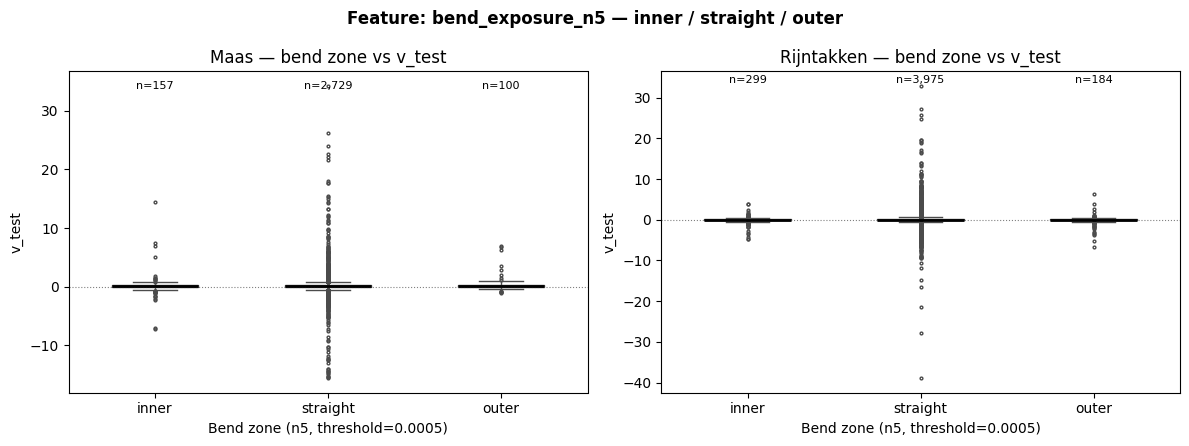

In [51]:
# (moved to Section 9)

zone_counts = (
    feat_ok.assign(system=np.where(maas_mask, 'Maas', 'Rijntakken'))
    .groupby(['system', 'bend_zone'], observed=True)
    .size().unstack(fill_value=0)
)
print('Scope regions per bend zone:')
display(zone_counts)

palette = {'inner': '#4575b4', 'straight': '#ffffbf', 'outer': '#d73027'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, (sys_name, mask) in zip(axes, systems.items()):
    sub = feat_ok.loc[mask].dropna(subset=['bend_zone', 'v_test'])
    order = ['inner', 'straight', 'outer']
    sns.boxplot(data=sub, x='bend_zone', y='v_test', order=order,
                palette=palette, width=0.5, fliersize=2,
                medianprops=dict(color='black', lw=2), ax=ax)
    for i, zone in enumerate(order):
        n = (sub['bend_zone'] == zone).sum()
        ax.text(i, ax.get_ylim()[1] * 0.92, f'n={n:,}', ha='center', fontsize=8)
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(f'{sys_name} — bend zone vs v_test')
    ax.set_xlabel('Bend zone (n5, threshold=0.0005)')

plt.suptitle('Feature: bend_exposure_n5 — inner / straight / outer', fontweight='bold')
plt.tight_layout()
plt.show()

## 10 — Feature: soil group (BRO Bodemkaart)

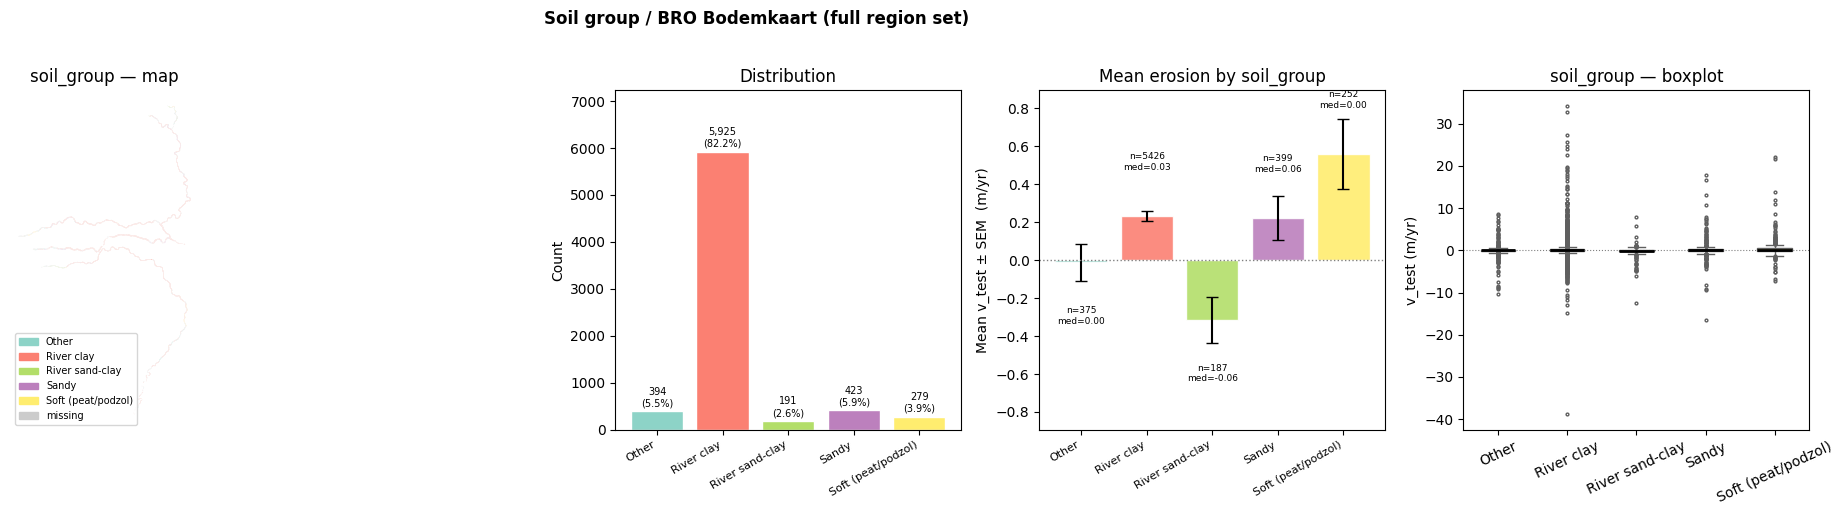

Distribution (full):
soil_group
River clay            5925
Sandy                  423
Other                  394
Soft (peat/podzol)     279
River sand-clay        191


In [52]:
soil_order = sorted(feat_all['soil_group'].dropna().unique())
feature_overview(
    scope_full, feat_all,
    col='soil_group',
    title='Soil group / BRO Bodemkaart (full region set)',
    feat_ok_df=feat_ok,
    order=soil_order,
    cmap='Set3',
)

print('Distribution (full):')
print(feat_all['soil_group'].value_counts().to_string())

## 11 — Feature: high-water metrics

All from cleaned discharge data using **consistent P90** for `flood_days` in both t1 and t2 windows.

In [53]:
HW_COLS = [
    'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1',
    'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2',
]

print('High-water metrics — Pearson / Spearman r with v_test (OK regions):\n')
print(f'{"Feature":<25} {"n":>6}  {"Pearson r":>10}  {"p":>10}  {"Spearman ρ":>10}')
print('─' * 70)
for col in HW_COLS:
    if col not in feat_ok.columns:
        continue
    sub = feat_ok[[col, 'v_test']].dropna()
    r,   p    = stats.pearsonr(sub[col], sub['v_test'])
    rho, _    = stats.spearmanr(sub[col], sub['v_test'])
    print(f'{col:<25} {len(sub):>6}  {r:>+10.4f}  {p:>10.2e}  {rho:>+10.4f}')

High-water metrics — Pearson / Spearman r with v_test (OK regions):

Feature                        n   Pearson r           p  Spearman ρ
──────────────────────────────────────────────────────────────────────
n_events_t1                 7444     +0.0458    7.78e-05     +0.0956
max_rise_rate_t1            7444     +0.0463    6.47e-05     +0.0736
drawdown_index_t1           7444     +0.0277    1.70e-02     +0.0432
flood_days_t1               7444     +0.0031    7.92e-01     +0.0458
n_events_t2                 7444     -0.0231    4.58e-02     +0.0089
max_rise_rate_t2            7444     +0.0256    2.69e-02     +0.0183
drawdown_index_t2           7444     -0.0112    3.35e-01     +0.0194
flood_days_t2               7444     -0.0302    9.13e-03     -0.0891


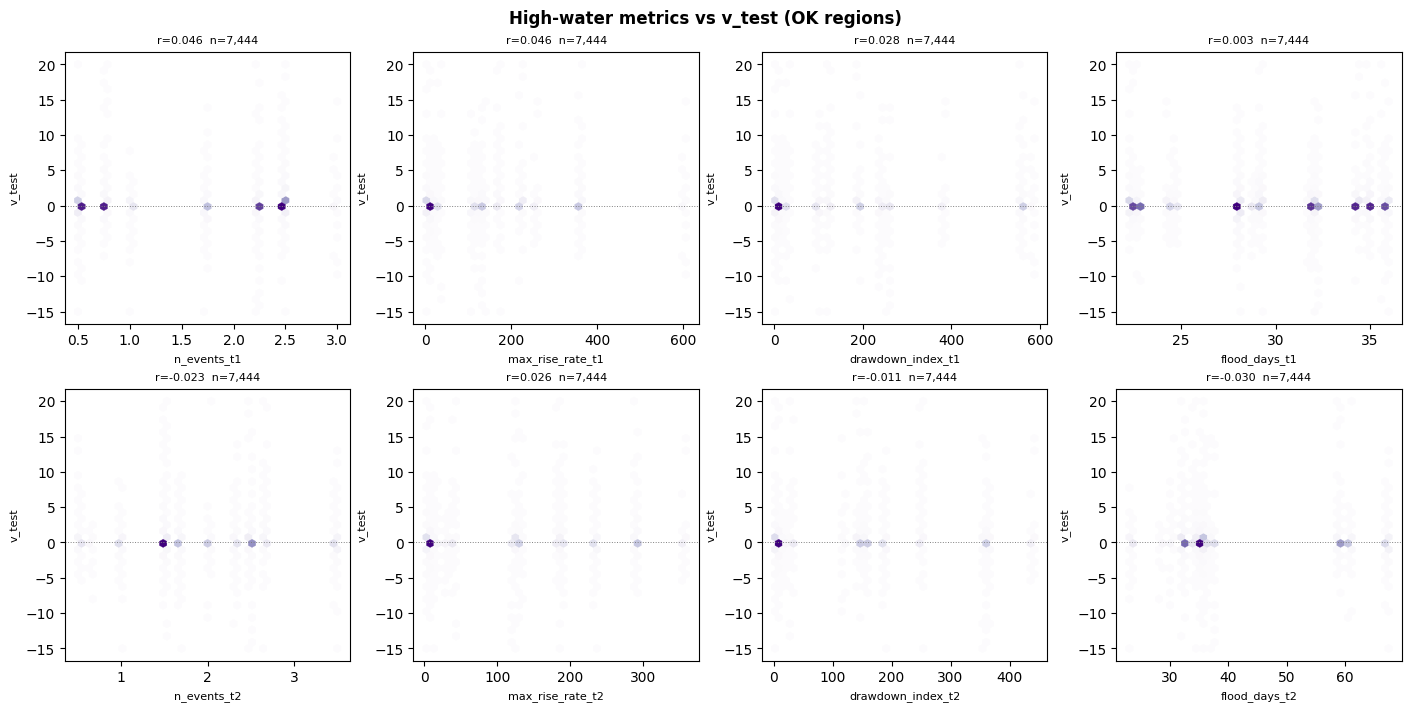

In [54]:
hw_present = [c for c in HW_COLS if c in feat_ok.columns]
n_cols = 4
n_rows = (len(hw_present) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), constrained_layout=True)
axes_flat = np.array(axes).flatten()

for i, col in enumerate(hw_present):
    ax = axes_flat[i]
    sub = feat_ok[[col, 'v_test']].dropna()
    r, _ = stats.pearsonr(sub[col], sub['v_test'])
    ax.hexbin(sub[col], sub['v_test'].clip(-15, 20),
              gridsize=35, cmap='Purples', mincnt=1, linewidths=0.2)
    ax.axhline(0, color='grey', lw=0.7, ls=':')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('v_test', fontsize=8)
    ax.set_title(f'r={r:.3f}  n={len(sub):,}', fontsize=8)

for ax in axes_flat[len(hw_present):]:
    ax.set_axis_off()

plt.suptitle('High-water metrics vs v_test (OK regions)', fontweight='bold')
plt.show()

## 10b — Station assignment overview

Derive nearest discharge station per scope region using the same river + chainage-based logic as the reference notebook.  
Source: `02_processed/water_stations/water_stations_for_modeling.gpkg`

In [55]:
import re

STATION_GPKG = DATA_DIR / '02_processed/water_stations/water_stations_for_modeling.gpkg'
stations = gpd.read_file(STATION_GPKG, layer='discharge_stations').set_index('CODE')
stations_rd = stations.to_crs(scope_full.crs)

# Parse chainage from location_id  e.g. maas3_r_15630_15640 → 15630
def parse_chainage(loc_id):
    m = re.search(r'_(\d+)_\d+$', str(loc_id))
    return int(m.group(1)) if m else None

# Build anchor: scope region closest to each station
scope_cent = gpd.GeoDataFrame(
    scope_full.copy(), geometry=scope_full.geometry.centroid, crs=scope_full.crs
)

def get_anchor(code):
    if code not in stations_rd.index:
        return None
    pt = stations_rd.loc[code, 'geometry']
    dists = scope_cent.geometry.distance(pt)
    return dists.idxmin()

anchor = {st: get_anchor(st) for st in stations_rd.index}
anchor = {k: v for k, v in anchor.items() if v is not None}

# Need chainage on the full set (feat_all) for assignment
feat_all_st = feat_all.copy()
feat_all_st['chainage'] = [parse_chainage(i) for i in feat_all_st.index]

# Anchor chainages for boundary cutoffs
def ch_of(anchor_dict, station_code, feat_df):
    loc = anchor_dict.get(station_code)
    return feat_df.loc[loc, 'chainage'] if loc and loc in feat_df.index else np.inf

megen_ch       = ch_of(anchor, 'megen.maas',           feat_all_st)
hank_ch        = ch_of(anchor, 'hank.bergschemaas',     feat_all_st)
olst_ch        = ch_of(anchor, 'olst',                  feat_all_st)
mill_ch        = ch_of(anchor, 'millingenaanderijn',     feat_all_st)
hag_ch         = ch_of(anchor, 'hagestein.boven',       feat_all_st)

# Westervoort boundary on Nederrijn
neder_mask = feat_all_st['river'] == 'nederrijn'
westervoort_pt = stations_rd.loc['westervoort.ijsselkop', 'geometry'] \
    if 'westervoort.ijsselkop' in stations_rd.index else None
if westervoort_pt is not None and neder_mask.any():
    neder_cent = scope_cent[scope_cent.index.isin(feat_all_st[neder_mask].index)]
    westervoort_ch = feat_all_st.loc[
        neder_cent.geometry.distance(westervoort_pt).idxmin(), 'chainage'
    ]
else:
    westervoort_ch = np.inf

# Assign stations
station_assigned = pd.Series(index=feat_all_st.index, dtype=object)
for loc_id, row in feat_all_st.iterrows():
    river = row['river']
    ch = row['chainage'] if pd.notna(row['chainage']) else 0
    if river == 'maas2':
        station_assigned[loc_id] = 'maastricht.borgharen.maas.beneden'
    elif river == 'maas1':
        station_assigned[loc_id] = 'maaseik'
    elif river == 'maas3':
        if ch < megen_ch:
            station_assigned[loc_id] = 'venlo'
        elif ch < hank_ch:
            station_assigned[loc_id] = 'megen.maas'
        else:
            station_assigned[loc_id] = 'hank.bergschemaas'
    elif river == 'ijssel1':
        station_assigned[loc_id] = 'olst' if ch >= olst_ch else 'westervoort.ijsselkop'
    elif river == 'ijssel2':
        station_assigned[loc_id] = 'genemuiden'
    elif river == 'rijn':
        station_assigned[loc_id] = 'millingenaanderijn' if ch >= mill_ch else 'lobith.bovenrijn.tolkamer'
    elif river == 'nederrijn':
        if ch <= westervoort_ch:
            station_assigned[loc_id] = 'pannerden.pannerdenschkanaal'
        elif ch < hag_ch:
            station_assigned[loc_id] = 'driel.boven'
        else:
            station_assigned[loc_id] = 'hagestein.boven'

feat_all_st['station'] = station_assigned
feat_ok['station'] = station_assigned.reindex(feat_ok.index)

print('Station assignment counts (full set):')
print(station_assigned.value_counts().to_string())
print(f'\nUnassigned: {station_assigned.isna().sum():,}')

Station assignment counts (full set):
venlo                                1825
millingenaanderijn                   1178
westervoort.ijsselkop                1132
driel.boven                           940
megen.maas                            879
olst                                  736
hagestein.boven                       545
genemuiden                            295
maastricht.borgharen.maas.beneden     198
pannerden.pannerdenschkanaal          151
maaseik                               127
lobith.bovenrijn.tolkamer              51
hank.bergschemaas                      37

Unassigned: 0


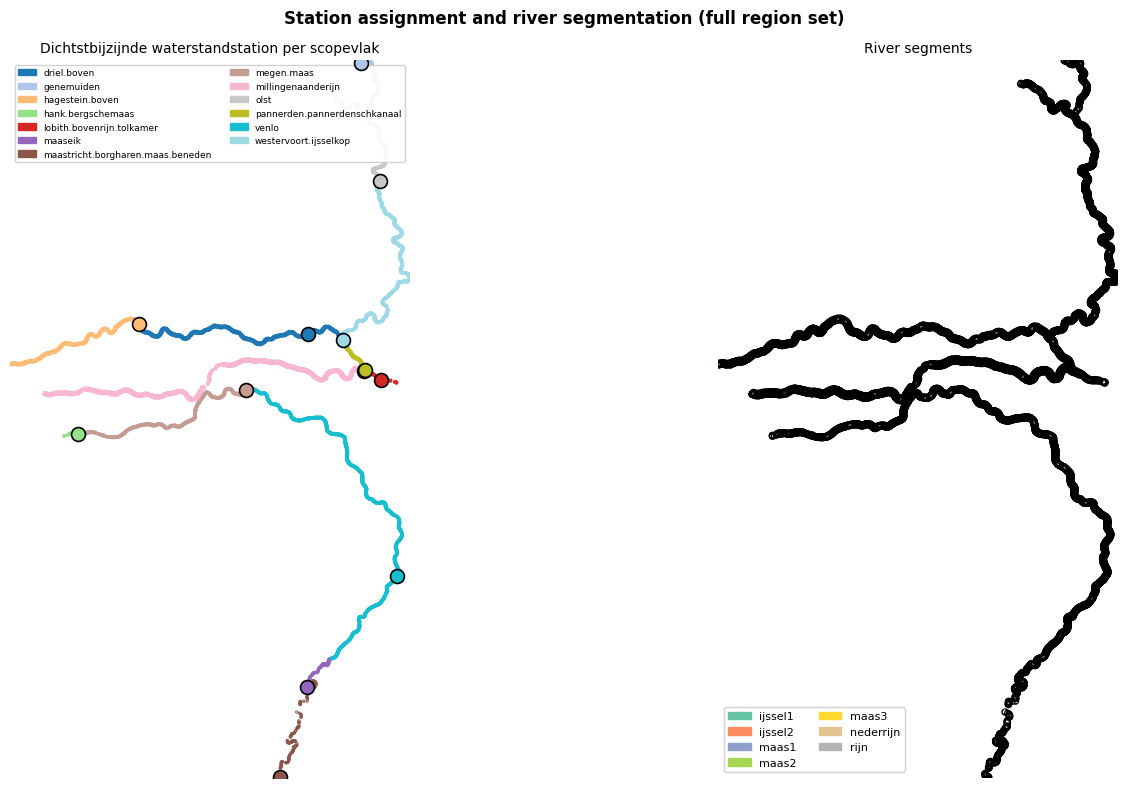


Station assignment summary (full set):
                                   n_regions      river
station                                                
venlo                                   1825      maas3
millingenaanderijn                      1178       rijn
westervoort.ijsselkop                   1132    ijssel1
driel.boven                              940  nederrijn
megen.maas                               879      maas3
olst                                     736    ijssel1
hagestein.boven                          545  nederrijn
genemuiden                               295    ijssel2
maastricht.borgharen.maas.beneden        198      maas2
pannerden.pannerdenschkanaal             151  nederrijn
maaseik                                  127      maas1
lobith.bovenrijn.tolkamer                 51       rijn
hank.bergschemaas                         37      maas3


In [79]:
# ── Station assignment map + river overview ───────────────────────────────────
station_order = sorted(feat_all_st['station'].dropna().unique())
n_st = len(station_order)
cmap_st = plt.get_cmap('tab20', n_st)
st_colors = {st: cmap_st(i) for i, st in enumerate(station_order)}

xmin, ymin, xmax, ymax = scope_full.total_bounds

fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={'width_ratios': [1, 1]})

# Left: station assignment map
ax = axes[0]
scope_plot_st = scope_full.join(feat_all_st[['station']], how='left')
scope_plot_st['_color'] = scope_plot_st['station'].map(st_colors).apply(
    lambda c: c if c is not None else (0.8, 0.8, 0.8, 1.0)
)
scope_plot_st.plot(color=list(scope_plot_st['_color']), ax=ax,
                   linewidth=2, edgecolor=scope_plot_st['_color'])
# Station dots
for code in station_order:
    if code in stations_rd.index:
        pt = stations_rd.loc[code, 'geometry']
        ax.scatter(pt.x, pt.y, s=100, color=[st_colors[code]],
                   edgecolor='black', linewidths=1.2, zorder=6)
handles_st = [mpatches.Patch(color=st_colors[st], label=st) for st in station_order]
ax.legend(handles=handles_st, loc='upper left', fontsize=6.5,
          framealpha=0.9, ncol=2)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal'); ax.set_axis_off()
ax.set_title('Dichtstbijzijnde waterstandstation per scopevlak', fontsize=10)

# Right: river segment map
river_order = sorted(feat_all_st['river'].dropna().unique())
cmap_rv = plt.get_cmap('Set2', len(river_order))
rv_colors = {rv: cmap_rv(i) for i, rv in enumerate(river_order)}

ax = axes[1]
scope_plot_rv = scope_full.join(feat_all_st[['river']], how='left')
scope_plot_rv['_color'] = scope_plot_rv['river'].map(rv_colors).apply(
    lambda c: c if c is not None else (0.85, 0.85, 0.85, 1.0)
)
scope_plot_rv.plot(color=list(scope_plot_rv['_color']), ax=ax,
                   linewidth=5, edgecolor='black')
handles_rv = [mpatches.Patch(color=rv_colors[rv], label=rv) for rv in river_order]
ax.legend(handles=handles_rv, loc='lower left', fontsize=8,
          framealpha=0.9, ncol=2)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal'); ax.set_axis_off()
ax.set_title('River segments', fontsize=10)

plt.suptitle('Station assignment and river segmentation (full region set)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print('\nStation assignment summary (full set):')
summary_st = (
    feat_all_st.groupby('station')
    .agg(n_regions=('river', 'count'), river=('river', lambda x: ', '.join(sorted(x.unique()))))
    .sort_values('n_regions', ascending=False)
)
print(summary_st.to_string())

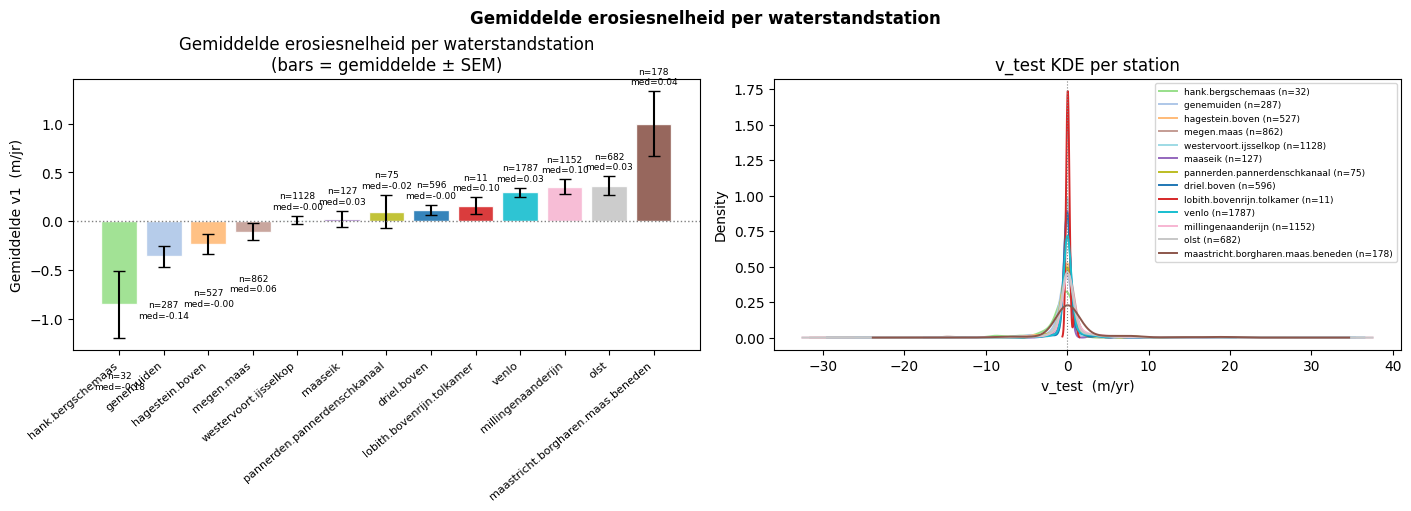

In [84]:
# ── Mean erosion (v_test) by nearest discharge station ────────────────────────
df_st = feat_ok[['station', 'v_test', 'river']].dropna(subset=['station', 'v_test'])

st_stats = (
    df_st.groupby('station')['v_test']
    .agg(mean='mean', sem=lambda x: x.sem(), n='count', median='median')
    .sort_values('mean')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: mean v_test per station with error bars
ax = axes[0]
x_pos = np.arange(len(st_stats))
bar_colors = [st_colors.get(st, '#888888') for st in st_stats.index]
ax.bar(x_pos, st_stats['mean'], yerr=st_stats['sem'], capsize=4,
       color=bar_colors, edgecolor='white', alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels(st_stats.index, rotation=40, ha='right', fontsize=8)
ax.axhline(0, color='grey', lw=1, ls=':')
ax.set_ylabel('Gemiddelde v1  (m/jr)')
ax.set_title('Gemiddelde erosiesnelheid per waterstandstation\n(bars = gemiddelde ± SEM)')
for xi, (st, row) in enumerate(st_stats.iterrows()):
    offset = row['sem'] + 0.05
    ax.text(xi, row['mean'] + offset if row['mean'] >= 0 else row['mean'] - offset - 0.3,
            f'n={int(row["n"])}\nmed={row["median"]:.2f}',
            ha='center', fontsize=6.5,
            va='bottom' if row['mean'] >= 0 else 'top')

# Right: v_test KDE per station
ax = axes[1]
for st in st_stats.index:
    sub = df_st.loc[df_st['station'] == st, 'v_test'].clip(-15, 20)
    if len(sub) > 10:
        sub.plot(kind='kde', ax=ax, color=st_colors.get(st, '#888888'),
                 label=f'{st} (n={len(sub)})', lw=1.4)
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('v_test  (m/yr)')
ax.set_title('v_test KDE per station')
ax.legend(fontsize=6.5, loc='upper right')

plt.suptitle('Gemiddelde erosiesnelheid per waterstandstation', fontweight='bold')
plt.show()

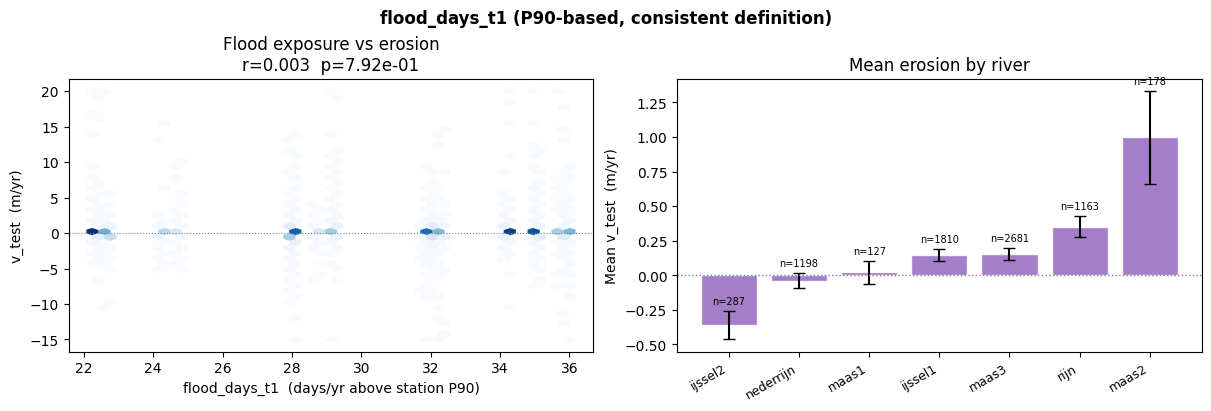

In [58]:
# Flood days: distribution (full set) and correlation by river (OK only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

df_fd = feat_ok[['flood_days_t1', 'v_test', 'river']].dropna()
r_fd, p_fd = stats.pearsonr(df_fd['flood_days_t1'], df_fd['v_test'])

ax = axes[0]
ax.hexbin(df_fd['flood_days_t1'], df_fd['v_test'].clip(-15, 20),
          gridsize=40, cmap='Blues', mincnt=1, linewidths=0.2)
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('flood_days_t1  (days/yr above station P90)')
ax.set_ylabel('v_test  (m/yr)')
ax.set_title(f'Flood exposure vs erosion\nr={r_fd:.3f}  p={p_fd:.2e}')

ax = axes[1]
rv_stats = (feat_ok.dropna(subset=['v_test'])
            .groupby('river')['v_test']
            .agg(mean='mean', sem=lambda x: x.sem(), n='count')
            .sort_values('mean'))
x_pos = np.arange(len(rv_stats))
ax.bar(x_pos, rv_stats['mean'], yerr=rv_stats['sem'], capsize=4,
       color='#9467bd', edgecolor='white', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(rv_stats.index, rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='grey', lw=1, ls=':')
ax.set_ylabel('Mean v_test  (m/yr)')
ax.set_title('Mean erosion by river')
for xi, (_, row) in enumerate(rv_stats.iterrows()):
    ax.text(xi, row['mean'] + row['sem'] + 0.05, f'n={int(row["n"])}',
            ha='center', fontsize=7)

plt.suptitle('flood_days_t1 (P90-based, consistent definition)', fontweight='bold')
plt.show()

*(Bend exposure analysis moved to Section 9 above.)*

In [59]:
# (moved to Section 9)

## 12 — Correlation matrix — all numeric features vs v_test

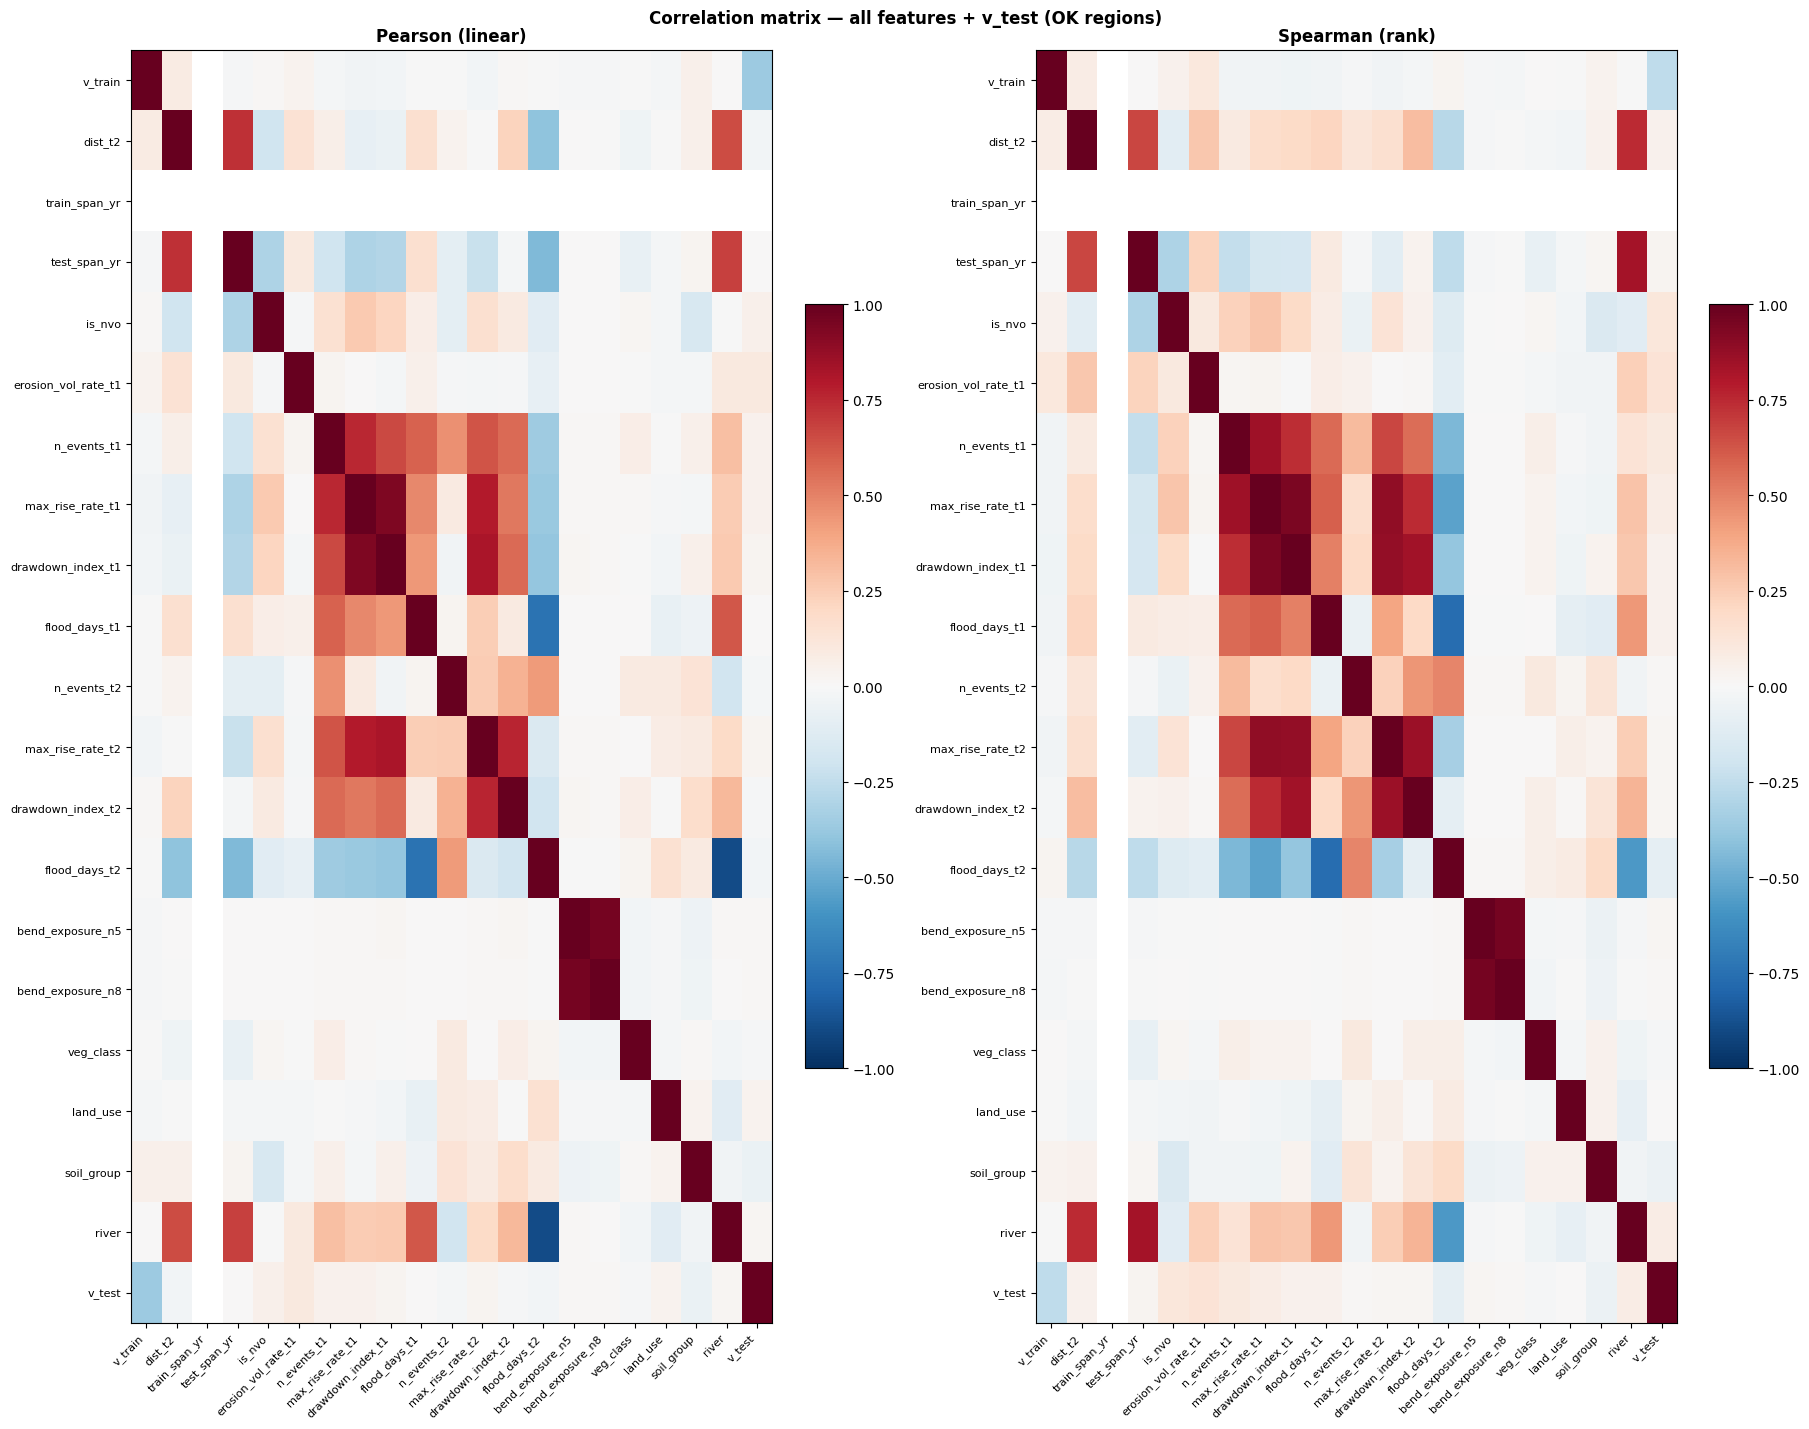

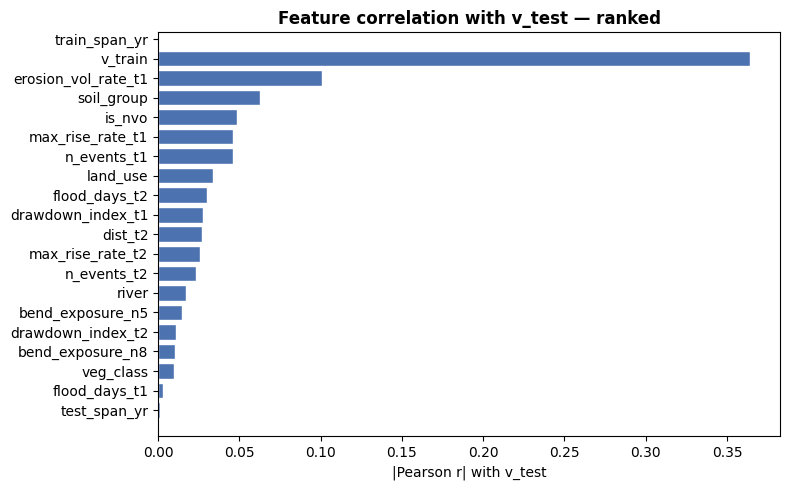

Top 10 features by |Pearson r| with v_test:
train_span_yr             NaN
v_train                0.3644
erosion_vol_rate_t1    0.1006
soil_group             0.0626
is_nvo                 0.0482
max_rise_rate_t1       0.0463
n_events_t1            0.0458
land_use               0.0335
flood_days_t2          0.0302
drawdown_index_t1      0.0277
Name: v_test, dtype: float64


In [60]:
# Encode categoricals numerically for correlation
corr_df = feat_ok.copy()
for cat_col in ['vegetation_class', 'land_use', 'soil_group', 'river']:
    if cat_col in corr_df.columns:
        le = LabelEncoder()
        corr_df[f'_{cat_col}_enc'] = le.fit_transform(
            corr_df[cat_col].fillna('__missing__')
        )

corr_cols = [
    'v_train', 'dist_t2', 'train_span_yr', 'test_span_yr',
    'is_nvo',
    'erosion_vol_rate_t1',
    'n_events_t1',    'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1',
    'n_events_t2',    'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2',
    'bend_exposure_n5', 'bend_exposure_n8',
    '_vegetation_class_enc', '_land_use_enc', '_soil_group_enc', '_river_enc',
    'v_test',
]
RENAME = {
    '_vegetation_class_enc': 'veg_class',
    '_land_use_enc':         'land_use',
    '_soil_group_enc':       'soil_group',
    '_river_enc':            'river',
}
corr_cols = [c for c in corr_cols if c in corr_df.columns]
mat = corr_df[corr_cols].rename(columns=RENAME).astype(float)

pearson  = mat.corr(method='pearson')
spearman = mat.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 14), constrained_layout=True)
for ax, corr_mat, title in [
    (axes[0], pearson,  'Pearson (linear)'),
    (axes[1], spearman, 'Spearman (rank)'),
]:
    im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr_mat.columns)))
    ax.set_xticklabels(corr_mat.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(corr_mat.index)))
    ax.set_yticklabels(corr_mat.index, fontsize=8)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.6)

plt.suptitle('Correlation matrix — all features + v_test (OK regions)', fontweight='bold', y=1.01)
plt.show()

# Ranked bar: |r| with v_test
vtest_corr = pearson['v_test'].drop('v_test').abs().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(vtest_corr.index, vtest_corr.values, color='#4c72b0', edgecolor='white')
ax.set_xlabel('|Pearson r| with v_test')
ax.set_title('Feature correlation with v_test — ranked', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features by |Pearson r| with v_test:')
print(vtest_corr[::-1].head(10).round(4))

## 13 — Train vs test split distribution check

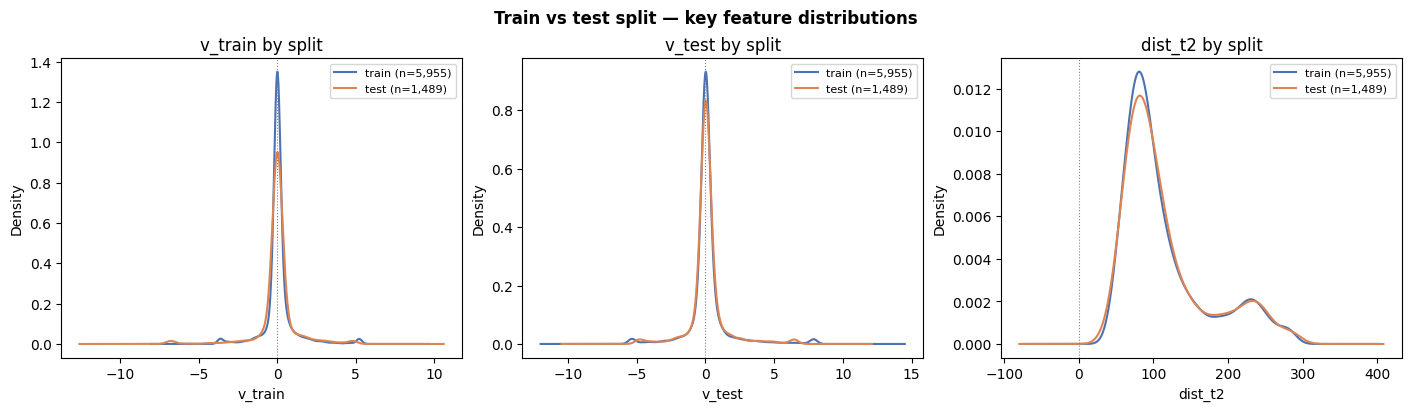

      v_train              v_test               dist_t2              
         mean    std count   mean    std count     mean     std count
split                                                                
test    0.009  1.762  1489  0.162  2.200  1489  115.044  58.955  1489
train   0.096  1.426  5955  0.147  2.183  5955  114.174  58.494  5955


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, col, label in [
    (axes[0], 'v_train', 'v_train'),
    (axes[1], 'v_test',  'v_test'),
    (axes[2], 'dist_t2', 'dist_t2'),
]:
    for split_val, color in [('train', '#4c72b0'), ('test', '#dd8452')]:
        sub = feat_ok.loc[feat_ok['split'] == split_val, col].dropna()
        sub.clip(sub.quantile(0.01), sub.quantile(0.99)).plot(
            kind='kde', ax=ax, color=color, label=f'{split_val} (n={len(sub):,})', lw=1.5
        )
    ax.set_xlabel(label)
    ax.set_title(f'{label} by split')
    ax.legend(fontsize=8)
    ax.axvline(0, color='grey', lw=0.8, ls=':')

plt.suptitle('Train vs test split — key feature distributions', fontweight='bold')
plt.show()

print(feat_ok.groupby('split')[['v_train', 'v_test', 'dist_t2']]
      .agg(['mean', 'std', 'count']).round(3))

## 14 — Coverage summary: missing values per feature

In [62]:
# Show % populated for every feature in the full and OK-only set
feature_cols = [
    'v_train', 'dist_t2', 'train_span_yr',
    'erosion_vol_rate_t1',
    'vegetation_class', 'land_use', 'soil_group',
    'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1',
    'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2',
    'bend_exposure_n5', 'bend_exposure_n8',
]

rows = []
for col in feature_cols:
    full_ok  = feat_all[col].notna().sum() if col in feat_all.columns else 0
    train_ok = feat_ok[col].notna().sum()  if col in feat_ok.columns  else 0
    rows.append({
        'feature':        col,
        'full_n_ok':      full_ok,
        'full_pct':       f'{full_ok / len(feat_all):.1%}',
        'OK_n_ok':        train_ok,
        'OK_pct':         f'{train_ok / len(feat_ok):.1%}',
    })

cov_df = pd.DataFrame(rows)
print(f'Full set size : {len(feat_all):,}   OK-only size : {len(feat_ok):,}\n')
print(cov_df.to_string(index=False))

Full set size : 8,094   OK-only size : 7,444

            feature  full_n_ok full_pct  OK_n_ok OK_pct
            v_train       8094   100.0%     7444 100.0%
            dist_t2       8094   100.0%     7444 100.0%
      train_span_yr       8094   100.0%     7444 100.0%
erosion_vol_rate_t1       8094   100.0%     7444 100.0%
   vegetation_class       5945    73.4%     5420  72.8%
           land_use       3094    38.2%     2871  38.6%
         soil_group       7212    89.1%     6639  89.2%
        n_events_t1       8094   100.0%     7444 100.0%
   max_rise_rate_t1       8094   100.0%     7444 100.0%
  drawdown_index_t1       8094   100.0%     7444 100.0%
      flood_days_t1       8094   100.0%     7444 100.0%
        n_events_t2       7444    92.0%     7444 100.0%
   max_rise_rate_t2       7444    92.0%     7444 100.0%
  drawdown_index_t2       7444    92.0%     7444 100.0%
      flood_days_t2       7444    92.0%     7444 100.0%
   bend_exposure_n5       7444    92.0%     7444 100.0%
  

---
## 15 — Stability analysis: erosion volume × v_test × NVO × soil type

`erosion_vol_rate_t1 = 0` is a stronger stability signal than `v_test ≤ 0` — it is a direct volumetric measurement rather than a derived velocity. Combining both gives a 2×2 stability matrix:

|  | vol_t1 = 0 | vol_t1 > 0 |
|--|------------|------------|
| **v_test ≤ 0** | Persistent stable ✅ | Reversal — was eroding, now stable 🔄 |
| **v_test > 0** | Recently started eroding ⚠️ | Persistent eroding 🔴 |

Three plots below, in order of narrative priority for stakeholders.

In [63]:
# ── Regions with BOTH erosion_vol_rate_t1 = 0 AND erosion_vol_rate_t2 = 0 ────
# vol_t2 lives in region_split.parquet as 'erosion_vol_test_rate'
split_df = pd.read_parquet(FEAT_DIR / 'region_split.parquet')

df_vol2 = feat_ok[['erosion_vol_rate_t1', 'v_test', 'is_nvo']].copy()
df_vol2['erosion_vol_rate_t2'] = split_df['erosion_vol_test_rate'].reindex(df_vol2.index)

mask_both_zero = (df_vol2['erosion_vol_rate_t1'] == 0) & (df_vol2['erosion_vol_rate_t2'] == 0)
mask_any_pos   = ~mask_both_zero

n_zero = mask_both_zero.sum()
n_pos  = mask_any_pos.sum()

print(f'Both vol_t1=0 AND vol_t2=0 : {n_zero:,}  ({n_zero/len(df_vol2):.1%})')
print(f'At least one vol > 0       : {n_pos:,}  ({n_pos/len(df_vol2):.1%})')
print()
for label, nvo_mask in [('NVO', df_vol2['is_nvo']), ('Non-NVO', ~df_vol2['is_nvo'])]:
    nz = (mask_both_zero & nvo_mask).sum()
    np_ = (mask_any_pos & nvo_mask).sum()
    print(f'  {label:8s} — both zero: {nz:,}  ({nz/(nz+np_):.1%})   any pos: {np_:,}  ({np_/(nz+np_):.1%})')

print()
print('v_test — both zero:')
print(df_vol2.loc[mask_both_zero, 'v_test'].describe().round(3))
print('\nv_test — at least one vol > 0:')
print(df_vol2.loc[mask_any_pos, 'v_test'].describe().round(3))

Both vol_t1=0 AND vol_t2=0 : 4,532  (60.9%)
At least one vol > 0       : 2,912  (39.1%)

  NVO      — both zero: 1,070  (53.9%)   any pos: 915  (46.1%)
  Non-NVO  — both zero: 3,462  (63.4%)   any pos: 1,997  (36.6%)

v_test — both zero:
count    4532.000
mean        0.087
std         2.001
min       -27.853
25%        -0.111
50%         0.000
75%         0.167
max        26.167
Name: v_test, dtype: float64

v_test — at least one vol > 0:
count    2912.000
mean        0.247
std         2.444
min       -38.896
25%        -0.125
50%         0.056
75%         0.375
max        34.273
Name: v_test, dtype: float64


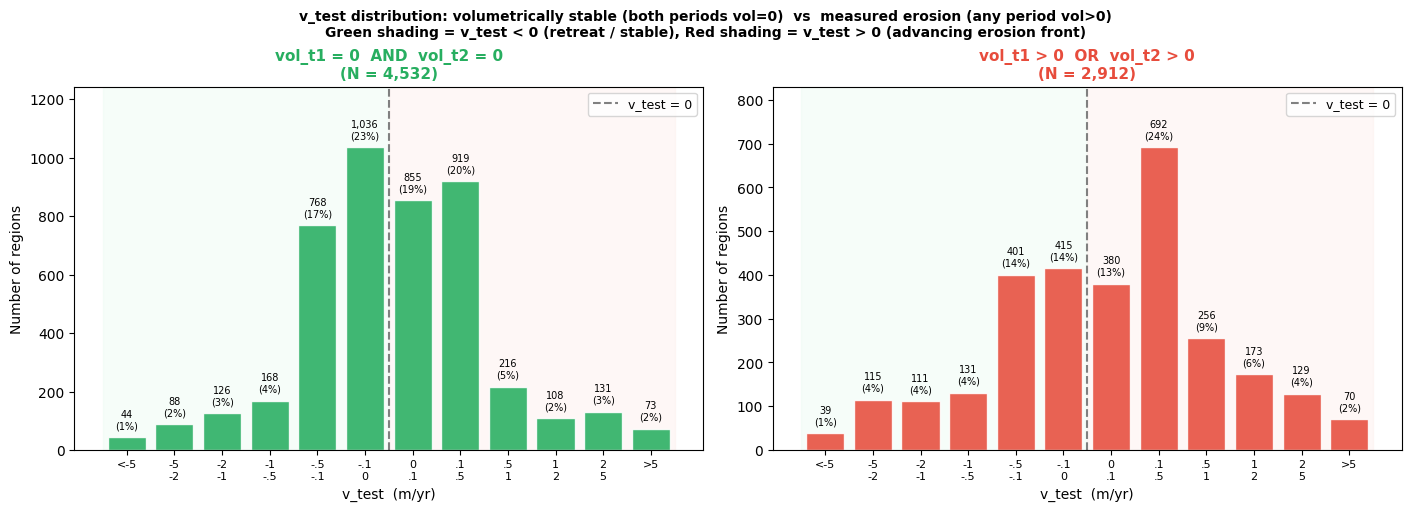

In [64]:
# ── Binned v_test histogram: vol=0 (both periods) vs vol>0 (any period) ───────
BINS = [-np.inf, -5, -2, -1, -0.5, -0.1, 0, 0.1, 0.5, 1, 2, 5, np.inf]
BIN_LABELS = ['<-5', '-5\n-2', '-2\n-1', '-1\n-.5', '-.5\n-.1', '-.1\n0',
              '0\n.1', '.1\n.5', '.5\n1', '1\n2', '2\n5', '>5']

grp_zero = df_vol2.loc[mask_both_zero, 'v_test'].dropna()
grp_pos  = df_vol2.loc[mask_any_pos,   'v_test'].dropna()

def bin_counts(series, bins):
    return pd.cut(series, bins=bins, include_lowest=True).value_counts(sort=False)

counts_zero = bin_counts(grp_zero, BINS)
counts_pos  = bin_counts(grp_pos,  BINS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True, sharey=False)

for ax, counts, grp, color, title in [
    (axes[0], counts_zero, grp_zero, '#27ae60',
     f'vol_t1 = 0  AND  vol_t2 = 0\n(N = {len(grp_zero):,})'),
    (axes[1], counts_pos,  grp_pos,  '#e74c3c',
     f'vol_t1 > 0  OR  vol_t2 > 0\n(N = {len(grp_pos):,})'),
]:
    x = np.arange(len(BIN_LABELS))
    bars = ax.bar(x, counts.values, color=color, edgecolor='white', alpha=0.88)

    # Annotate n + % per bar
    total = counts.sum()
    for xi, val in enumerate(counts.values):
        if val > 0:
            ax.text(xi, val + total * 0.005,
                    f'{val:,}\n({val/total:.0%})',
                    ha='center', va='bottom', fontsize=7)

    # Vertical line at x=0 (between bins -.1→0 and 0→.1, i.e. between index 5 and 6)
    ax.axvline(x=5.5, color='grey', lw=1.5, ls='--', label='v_test = 0')

    ax.set_xticks(x)
    ax.set_xticklabels(BIN_LABELS, fontsize=8)
    ax.set_xlabel('v_test  (m/yr)', fontsize=10)
    ax.set_ylabel('Number of regions', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.set_ylim(0, counts.max() * 1.20)

    # Shade negative half
    ax.axvspan(-0.5, 5.5, color='#eafaf1', alpha=0.4, zorder=0)
    ax.axvspan(5.5, len(BIN_LABELS) - 0.5, color='#fdecea', alpha=0.4, zorder=0)

plt.suptitle(
    'v_test distribution: volumetrically stable (both periods vol=0)  vs  measured erosion (any period vol>0)\n'
    'Green shading = v_test < 0 (retreat / stable), Red shading = v_test > 0 (advancing erosion front)',
    fontweight='bold', fontsize=10
)
plt.show()

### Spatial view: volumetrically stable but measured as eroding

Select the 10 regions with the **largest `v_test`** where both `erosion_vol_rate_t1 = 0`
and `erosion_vol_rate_t2 = 0` — i.e. no erosion was captured in the polygon dataset yet the
bank position clearly moved outward. Draws historical bank points and the scope boundary so
we can visually inspect whether these are true erosion signals or artefacts.

Loading geometric data ...
  Centrelines : 12,130
  Bank points : 4,844,655

Ghost erosion candidates (vol=0, v_test>0): 2,302
Plotting top 10 by v_test:
  maas3_r_7520_7530                    v_test=+26.17  nvo=False
  rijn_r_7300_7310                     v_test=+25.71  nvo=False
  maas3_l_14740_14750                  v_test=+24.06  nvo=False
  maas3_r_8910_8920                    v_test=+21.54  nvo=False
  rijn_l_6400_6410                     v_test=+19.67  nvo=False
  rijn_r_5270_5280                     v_test=+19.62  nvo=False
  maas3_l_17590_17600                  v_test=+18.11  nvo=True
  ijssel1_r_8170_8180                  v_test=+17.25  nvo=True
  maas3_r_7470_7480                    v_test=+15.47  nvo=False
  maas3_l_17520_17530                  v_test=+15.33  nvo=True


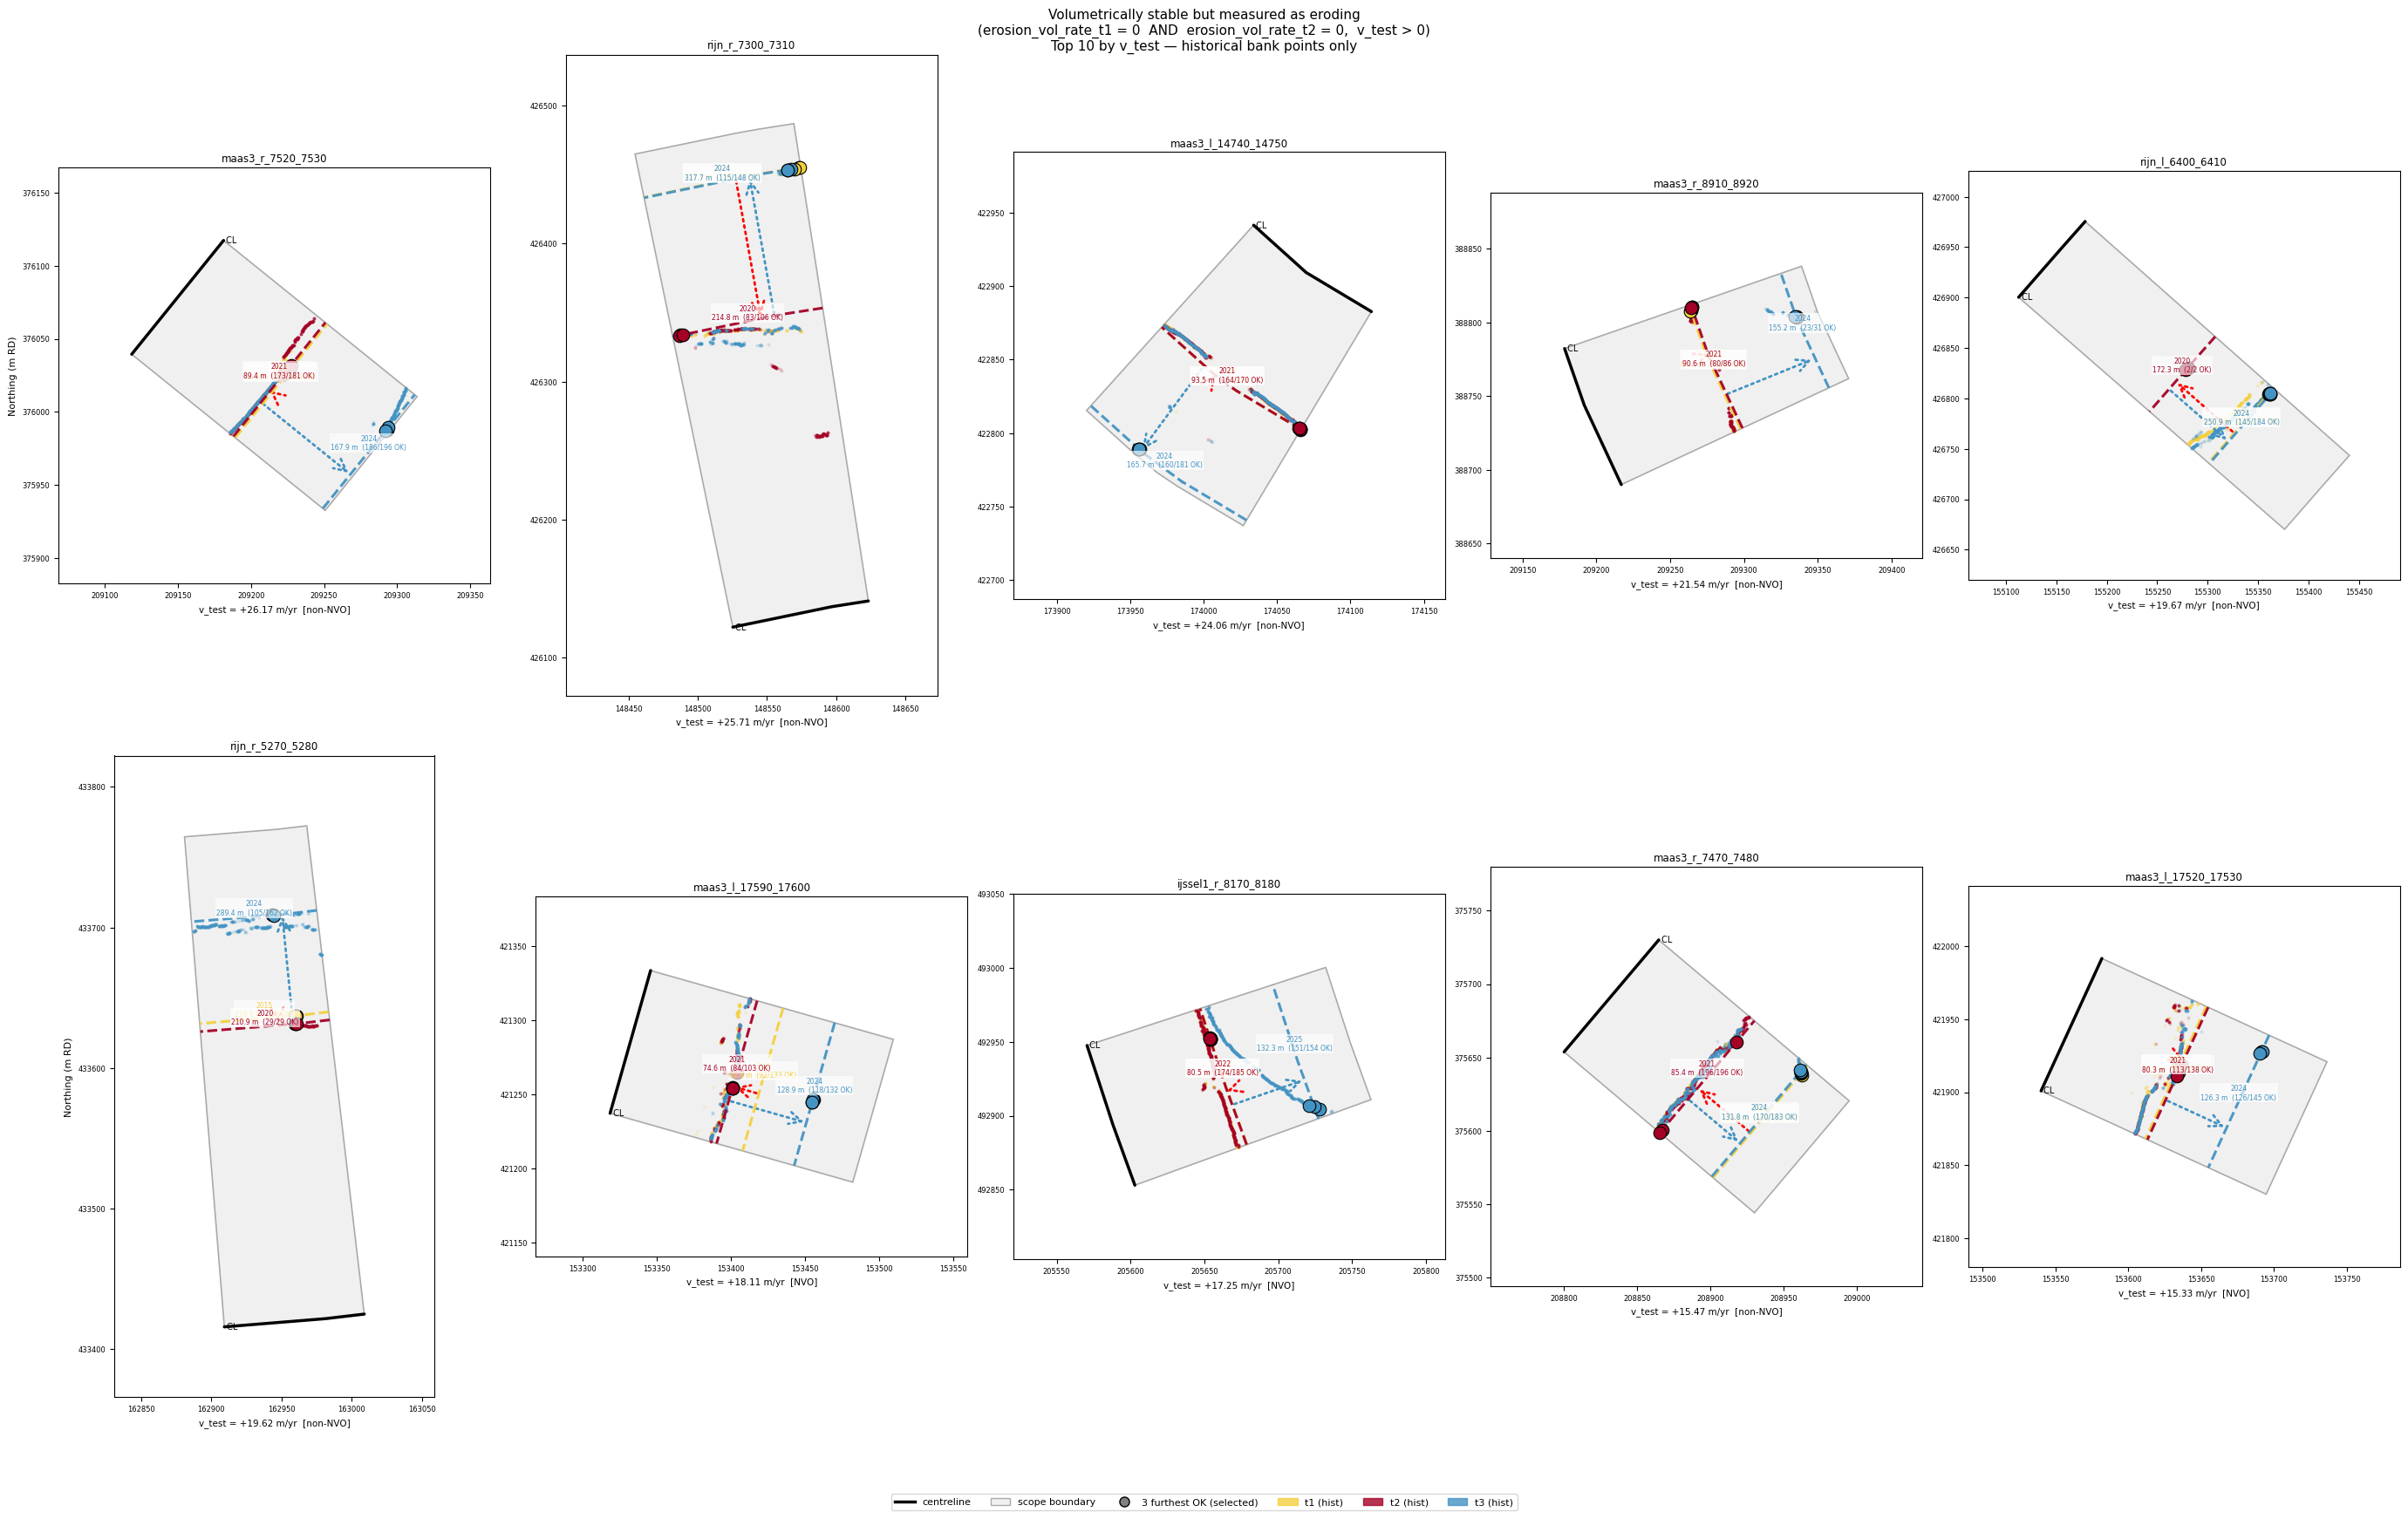

In [65]:
import matplotlib.cm as cm
from src.erosion.plot_utils import draw_region, plot_regions, make_legend_handles
from src.erosion.centerline_utils import ensure_location_id_column

# ── Load geometric data (not yet in notebook scope) ──────────────────────────
print('Loading geometric data ...')
centrelines  = ensure_location_id_column(gpd.read_file(RAW_GPKG, layer='centrelines'))
bank_points  = ensure_location_id_column(gpd.read_file(RAW_GPKG, layer='punten_oever'))

cl_lookup    = centrelines.set_index('location_id')['geometry'].to_dict()
scope_lookup = (scope_raw
                .rename(columns={'position_id': 'location_id'})
                .set_index('location_id')['geometry']
                .to_dict())
print(f'  Centrelines : {len(cl_lookup):,}')
print(f'  Bank points : {len(bank_points):,}')

# ── Pick 10 "ghost erosion" regions: both vol = 0, v_test > 0 ────────────────
# df_vol2 and mask_both_zero are defined in the stability setup cell above.
mask_ghost = mask_both_zero & (df_vol2['v_test'] > 0)
ghost_locs = (
    df_vol2.loc[mask_ghost, 'v_test']
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print(f'\nGhost erosion candidates (vol=0, v_test>0): {mask_ghost.sum():,}')
print(f'Plotting top 10 by v_test:')
for loc in ghost_locs:
    row = df_vol2.loc[loc]
    print(f'  {loc:35s}  v_test={row["v_test"]:+.2f}  nvo={bool(row["is_nvo"])}')

# ── Per-panel label: show v_test and NVO status ───────────────────────────────
def _ghost_xlabel(loc_id):
    if loc_id not in df_vol2.index:
        return loc_id
    row = df_vol2.loc[loc_id]
    nvo = 'NVO' if row['is_nvo'] else 'non-NVO'
    return f"v_test = {row['v_test']:+.2f} m/yr  [{nvo}]"

# ── Legend (bank points only, no predictions or VVR needed here) ─────────────
legend_handles = make_legend_handles(
    pred_colors=[], pred_years=[],
    show_vvr=False, show_signaleringslijn=False,
)

plot_regions(
    ghost_locs,
    title=(
        'Volumetrically stable but measured as eroding\n'
        '(erosion_vol_rate_t1 = 0  AND  erosion_vol_rate_t2 = 0,  v_test > 0)\n'
        'Top 10 by v_test — historical bank points only'
    ),
    legend_handles=legend_handles,
    cl_lookup=cl_lookup,
    scope_lookup=scope_lookup,
    bank_points=bank_points,
    draw_kwargs=dict(
        show_bank_points=True,
        show_t1_to_t2_arrow=True,
        show_predictions=False,
        show_vvr=False,
        show_signaleringslijn=False,
    ),
    per_region_xlabel=_ghost_xlabel,
    n_cols=5,
    fig_w=5.5,
    fig_h=8.0,
)

### Stability segmentation: three categories

Three mutually exclusive categories based on `v_train` and `v_test`:

| Category | Condition | Colour |
|---|---|---|
| **Structurally stable** | `\|v_train\| < 0.05 AND \|v_test\| < 0.05` | green |
| **Non-eroding, dynamic** | `v_train ≤ 0.05 AND v_test ≤ 0.05` but NOT stable (sedimenting) | light green |
| **Eroding / variable** | `v_train > 0.05 OR v_test > 0.05` | orange–red |

Plots: horizontal stacked bar (overall + NVO split), map, table per river, forward check.

── Stabiliteitssegmentatie ──────────────────────────────────────────────
  Structureel stabiel                         674  (9.1%)
  Niet-eroderend, wel sedimenterend         1,494  (20.1%)
  Eroderend                                 5,276  (70.9%)
  TOTAAL                                    7,444


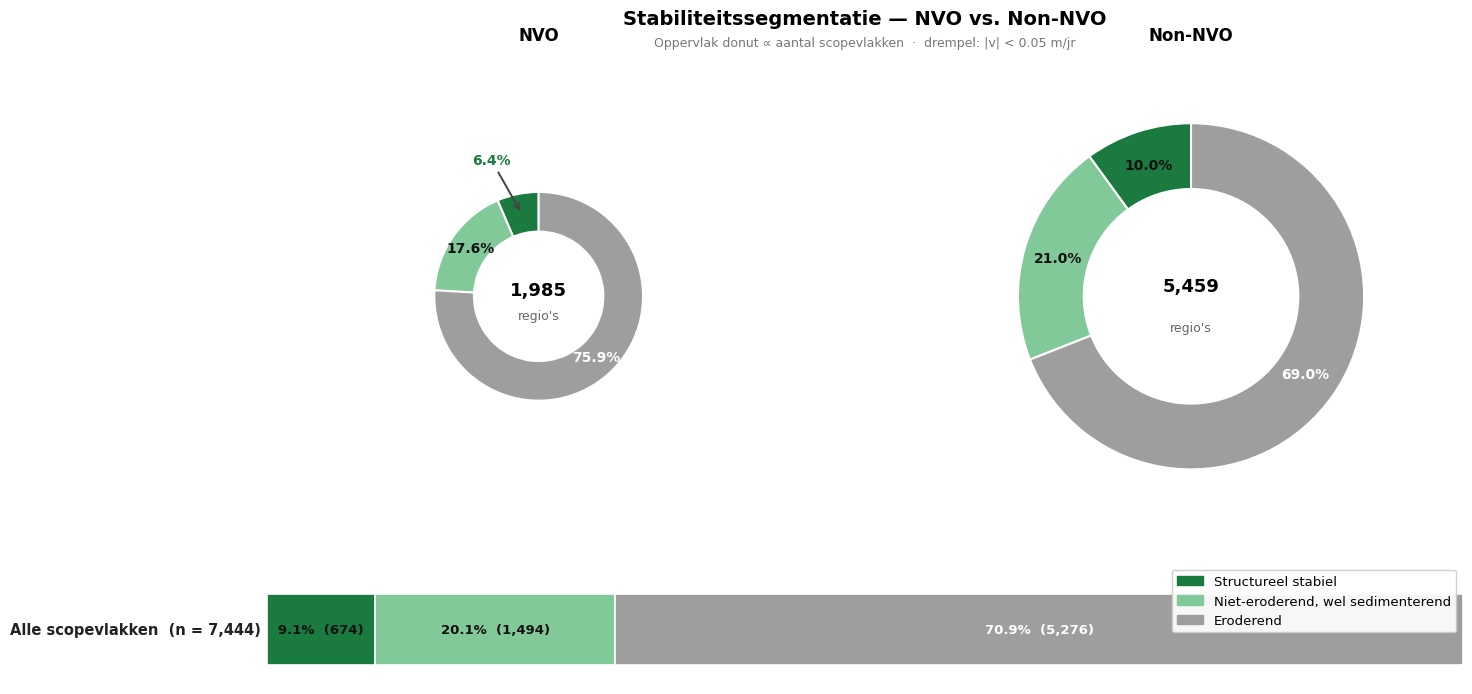

,Structureel stabiel,"Niet-eroderend, wel sedimenterend",Eroderend,n
river,,,,
ijssel1,8.5%,20.7%,70.9%,"1,810"
ijssel2,6.3%,24.7%,69.0%,287
maas1,13.4%,27.6%,59.1%,127
maas2,5.1%,24.7%,70.2%,178
maas3,8.7%,19.8%,71.5%,"2,681"
nederrijn,14.6%,23.8%,61.6%,"1,198"
rijn,5.9%,13.3%,80.7%,"1,163"
TOTAAL,9.1%,20.1%,70.9%,"7,444"


In [66]:
THRESH = 0.05  # m/jr

df_vstab = feat_ok[['v_train', 'v_test', 'is_nvo', 'river']].dropna(subset=['v_train', 'v_test']).copy()

mask_struct  = (df_vstab['v_train'].abs() < THRESH) & (df_vstab['v_test'].abs() < THRESH)
mask_nonerod = (df_vstab['v_train'] <= THRESH) & (df_vstab['v_test'] <= THRESH)
mask_dynamic = mask_nonerod & ~mask_struct
mask_eroding = ~mask_nonerod

df_vstab['category'] = np.select(
    [mask_struct, mask_dynamic],
    ['Structureel stabiel', 'Niet-eroderend, wel sedimenterend'],
    default='Eroderend',
)

n_total   = len(df_vstab)
CAT_ORDER  = ['Structureel stabiel', 'Niet-eroderend, wel sedimenterend', 'Eroderend']
CAT_COLORS = {
    'Structureel stabiel':              '#1a7a40',
    'Niet-eroderend, wel sedimenterend': '#82c99a',
    'Eroderend':                         '#9e9e9e',
}

counts = df_vstab['category'].value_counts().reindex(CAT_ORDER)
pcts   = counts / n_total * 100

nvo_sub    = df_vstab[df_vstab['is_nvo'].astype(bool)]
nonnvo_sub = df_vstab[~df_vstab['is_nvo'].astype(bool)]

print('── Stabiliteitssegmentatie ──────────────────────────────────────────────')
for cat in CAT_ORDER:
    print(f'  {cat:40s}  {counts[cat]:5,}  ({pcts[cat]:.1f}%)')
print(f'  {"TOTAAL":40s}  {n_total:5,}')

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 7.5))
gs  = fig.add_gridspec(2, 2, height_ratios=[4, 1.0], hspace=0.08,
                        left=0.04, right=0.96, top=0.90, bottom=0.06)
ax_nvo    = fig.add_subplot(gs[0, 0])
ax_nonnvo = fig.add_subplot(gs[0, 1])
ax_total  = fig.add_subplot(gs[1, :])

# Proportional radii: oppervlak ∝ n  →  radius ∝ sqrt(n)
r_nonnvo = 1.00
r_nvo    = np.sqrt(len(nvo_sub) / len(nonnvo_sub))   # ≈ 0.60

def draw_donut(ax, subset, title, radius):
    n          = len(subset)
    cat_counts = subset['category'].value_counts().reindex(CAT_ORDER).fillna(0)
    cat_pcts   = cat_counts / n * 100
    ring_w     = 0.38 * radius

    wedges, _, autotexts = ax.pie(
        cat_counts,
        colors=[CAT_COLORS[c] for c in CAT_ORDER],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.80,
        radius=radius,
        wedgeprops=dict(width=ring_w, edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=10),
    )

    for at, cat, pct in zip(autotexts, CAT_ORDER, cat_pcts):
        if pct < 10:
            at.set_text('')
        else:
            at.set_color('white' if cat == 'Eroderend' else '#111')
            at.set_fontweight('bold')
            at.set_fontsize(10)

    # Callout voor smalle segmenten (< 10%)
    for i, (cat, pct) in enumerate(zip(CAT_ORDER, cat_pcts)):
        if 0 < pct < 10:
            mid_angle = wedges[i].theta1 + (wedges[i].theta2 - wedges[i].theta1) / 2
            rad  = np.deg2rad(mid_angle)
            sign = 1 if np.cos(rad) >= 0 else -1
            x_tip = (radius - ring_w / 2) * np.cos(rad)
            y_tip = (radius - ring_w / 2) * np.sin(rad)
            x_lbl = (radius + 0.20) * np.cos(rad)
            y_lbl = (radius + 0.20) * np.sin(rad)
            ax.annotate(
                f'{pct:.1f}%',
                xy=(x_tip, y_tip), xytext=(x_lbl, y_lbl),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.4),
                ha='left' if sign > 0 else 'right',
                va='center', fontsize=10, fontweight='bold',
                color=CAT_COLORS[cat],
            )

    ax.text(0,  0.06 * radius, f'{n:,}',    ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(0, -0.18 * radius, "regio's",   ha='center', va='center', fontsize=9, color='#666')
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

draw_donut(ax_nvo,    nvo_sub,    'NVO',     r_nvo)
draw_donut(ax_nonnvo, nonnvo_sub, 'Non-NVO', r_nonnvo)

# ── Legenda: rechtsonder ──────────────────────────────────────────────────────
handles_leg = [mpatches.Patch(color=CAT_COLORS[c], label=c) for c in CAT_ORDER]
fig.legend(handles=handles_leg,
           loc='lower right', bbox_to_anchor=(0.96, 0.12),
           fontsize=9.5, framealpha=0.92, edgecolor='#ccc')

# ── Totaalbalk ────────────────────────────────────────────────────────────────
ax_total.set_xlim(0, 100)
ax_total.set_ylim(-0.45, 0.55)
ax_total.set_axis_off()

left = 0
for cat in CAT_ORDER:
    pct = pcts[cat]
    n   = int(counts[cat])
    ax_total.barh(0, pct, left=left, height=0.58,
                  color=CAT_COLORS[cat], edgecolor='white', linewidth=1.2)
    if pct >= 9:
        ax_total.text(left + pct / 2, 0,
                      f'{pct:.1f}%  ({n:,})',
                      ha='center', va='center', fontsize=9.5, fontweight='bold',
                      color='white' if cat == 'Eroderend' else '#111')
    else:
        ax_total.annotate(
            f'{pct:.1f}%  ({n:,})',
            xy=(left + pct / 2, 0.29), xytext=(left + pct / 2, 0.50),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.0),
            ha='center', va='bottom', fontsize=9, color='#333',
        )
    left += pct

ax_total.text(-0.5, 0, f'Alle scopevlakken  (n = {n_total:,})',
              va='center', ha='right', fontsize=10.5, fontweight='bold', color='#222')

# ── Titel ─────────────────────────────────────────────────────────────────────
fig.suptitle('Stabiliteitssegmentatie — NVO vs. Non-NVO',
             fontsize=14, fontweight='bold', y=0.96)
fig.text(0.5, 0.91,
         'Oppervlak donut ∝ aantal scopevlakken  ·  drempel: |v| < 0.05 m/jr',
         ha='center', fontsize=9, color='#777')

plt.show()

# ── Tabel per rivier ──────────────────────────────────────────────────────────
river_tbl = (
    df_vstab.groupby('river')['category']
    .value_counts(normalize=True).mul(100).unstack(fill_value=0)
    .reindex(columns=CAT_ORDER).round(1)
    .join(df_vstab.groupby('river').size().rename('n'))
)
river_tbl.loc['TOTAAL'] = list(counts / n_total * 100) + [n_total]
river_tbl = river_tbl.astype({'n': int})
display(
    river_tbl.style
    .format({c: '{:.1f}%' for c in CAT_ORDER} | {'n': '{:,}'})
    .background_gradient(cmap='Greens', subset=['Structureel stabiel'],              axis=0)
    .background_gradient(cmap='Greys',  subset=['Eroderend'],                        axis=0)
    .set_caption(f'Drempelwaarde: |v| < {THRESH} m/jr')
)

── Forward check: predicted crossing year for each stability category ───
Structurally stable             n=674  | stays stable (9999): 83 (12.3%)  | will cross: 28 (4.2%)  | no VVR: 563 (83.5%)
Non-eroding, dynamic            n=1,494  | stays stable (9999): 200 (13.4%)  | will cross: 82 (5.5%)  | no VVR: 1,212 (81.1%)
Eroding / variable              n=5,276  | stays stable (9999): 903 (17.1%)  | will cross: 374 (7.1%)  | no VVR: 3,999 (75.8%)


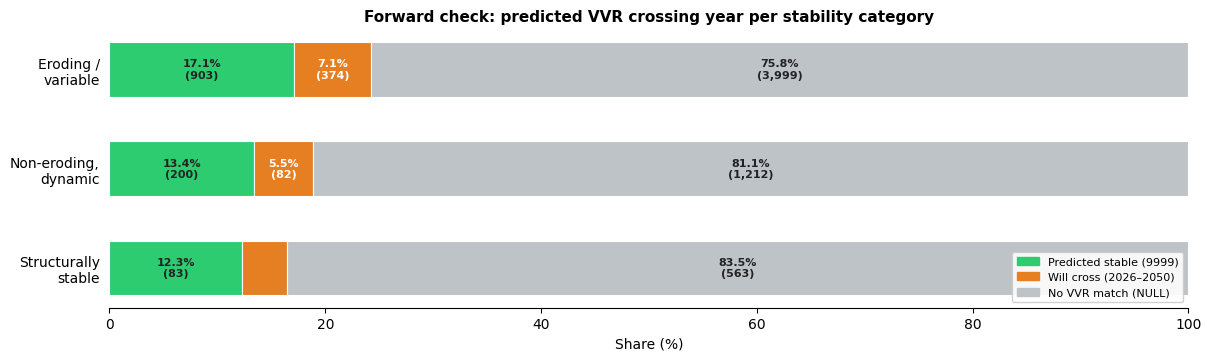

In [67]:
# ── Forward check: do stable/non-eroding regions stay that way in the prediction? ─
# stable_locs from mask_struct above; also check non-eroding group (mask_nonerod)
_PRED_GPKG  = DATA_DIR / f'04_model_outputs/{EXPERIMENT}/wocu_lgb_predictions_{EXPERIMENT}.gpkg'
_scope_sg   = gpd.read_file(_PRED_GPKG, layer='summary_scope').rename(columns={'position_id': 'location_id'})
_vvr_sg     = gpd.read_file(_PRED_GPKG, layer='vvr_rates_of_change')
_scope_sg   = _scope_sg.to_crs(_vvr_sg.crs)

_joined = (gpd.sjoin(_scope_sg[['location_id', 'geometry']],
                     _vvr_sg[['predicted_vvr_crossing_year', 'geometry']],
                     how='left', predicate='intersects')
           .drop_duplicates('location_id')
           .set_index('location_id'))
cy = _joined['predicted_vvr_crossing_year']

def forward_stats(locs, label):
    cy_g = cy.reindex(locs)
    n = len(locs)
    n_9999   = (cy_g == 9999).sum()
    n_cross  = cy_g.between(2026, 2050).sum()
    n_null   = cy_g.isna().sum()
    print(f'{label:30s}  n={n:,}  '
          f'| stays stable (9999): {n_9999:,} ({n_9999/n*100:.1f}%)  '
          f'| will cross: {n_cross:,} ({n_cross/n*100:.1f}%)  '
          f'| no VVR: {n_null:,} ({n_null/n*100:.1f}%)')
    return cy_g

print('── Forward check: predicted crossing year for each stability category ───')
struct_locs   = df_vstab[mask_struct].index
dynamic_locs  = df_vstab[mask_dynamic].index
eroding_locs  = df_vstab[mask_eroding].index

cy_struct  = forward_stats(struct_locs,  'Structurally stable')
cy_dynamic = forward_stats(dynamic_locs, 'Non-eroding, dynamic')
cy_eroding = forward_stats(eroding_locs, 'Eroding / variable')

# ── Plot: one stacked bar per category showing forward outcome ────────────────
def crossing_outcome(cy_series):
    n = len(cy_series)
    return {
        'Predicted stable\n(9999)':    (cy_series == 9999).sum(),
        'Will cross\n(2026\u20132050)': cy_series.between(2026, 2050).sum(),
        'No VVR match\n(NULL)':         cy_series.isna().sum(),
    }

FWD_COLORS = {'Predicted stable\n(9999)': '#2ecc71',
              'Will cross\n(2026\u20132050)': '#e67e22',
              'No VVR match\n(NULL)': '#bdc3c7'}

cats_data = [
    ('Structurally\nstable',    cy_struct,  len(struct_locs)),
    ('Non-eroding,\ndynamic',   cy_dynamic, len(dynamic_locs)),
    ('Eroding /\nvariable',     cy_eroding, len(eroding_locs)),
]

fig, ax = plt.subplots(figsize=(12, 3.5), constrained_layout=True)
for yi, (cat_label, cy_series, n_cat) in enumerate(cats_data):
    outcome = crossing_outcome(cy_series)
    left = 0
    for fwd_label, cnt in outcome.items():
        pct = cnt / n_cat * 100
        bar_color = FWD_COLORS[fwd_label]
        ax.barh(yi, pct, left=left, height=0.55,
                color=bar_color, edgecolor='white', linewidth=0.8)
        if pct >= 5:
            ax.text(left + pct / 2, yi,
                    f'{pct:.1f}%\n({cnt:,})',
                    ha='center', va='center', fontsize=8,
                    color='white' if 'Will cross' in fwd_label else '#222',
                    fontweight='bold')
        left += pct

ax.set_yticks(range(len(cats_data)))
ax.set_yticklabels([c[0] for c in cats_data], fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel('Share (%)', fontsize=10)
ax.set_title('Forward check: predicted VVR crossing year per stability category',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)

handles_fwd = [mpatches.Patch(color=FWD_COLORS[l], label=l.replace('\n', ' ')) for l in FWD_COLORS]
ax.legend(handles=handles_fwd, loc='lower right', fontsize=8, framealpha=0.9)
plt.show()

In [68]:
# (duplicate removed — forward check is in cell 57 above)
_PRED_GPKG  = DATA_DIR / f'04_model_outputs/{EXPERIMENT}/wocu_lgb_predictions_{EXPERIMENT}.gpkg'
_scope_sg   = gpd.read_file(_PRED_GPKG, layer='summary_scope').rename(columns={'position_id': 'location_id'})
_vvr_sg     = gpd.read_file(_PRED_GPKG, layer='vvr_rates_of_change')
_scope_sg   = _scope_sg.to_crs(_vvr_sg.crs)

_joined = (gpd.sjoin(_scope_sg[['location_id', 'geometry']],
                     _vvr_sg[['predicted_vvr_crossing_year', 'geometry']],
                     how='left', predicate='intersects')
           .drop_duplicates('location_id')
           .set_index('location_id'))

crossing_per_loc = _joined['predicted_vvr_crossing_year']

# Map onto stable locations
stable_locs = df_vstab[mask_stable].index
cy_stable   = crossing_per_loc.reindex(stable_locs)

n_stable_nvo     = df_vstab.loc[stable_locs, 'is_nvo'].astype(bool).sum()
n_stable_non_nvo = len(stable_locs) - n_stable_nvo

# Classify forward outcome
cy_cat = pd.cut(
    cy_stable.fillna(-1),
    bins=[-2, 0, 2026, 2034, 2050, 9998, 9999],
    labels=['No VVR match (NULL)', '≤ 2026', '2027–2034', '2035–2050', '—', 'No crossing (9999)'],
    right=True,
)
cy_counts = cy_cat.value_counts().reindex(
    ['≤ 2026', '2027–2034', '2035–2050', 'No crossing (9999)', 'No VVR match (NULL)']
).fillna(0).astype(int)

n_pred_stable = int(cy_counts.get('No crossing (9999)', 0))
pct_pred_stable = n_pred_stable / len(stable_locs) * 100 if len(stable_locs) else 0

print(f'Historically stable locations  : {len(stable_locs):,}')
print(f'  Of which NVO                 : {n_stable_nvo:,}')
print(f'  Of which Non-NVO             : {n_stable_non_nvo:,}')
print(f'\nForward prediction outcome:')
for cat, cnt in cy_counts.items():
    pct = cnt / len(stable_locs) * 100
    flag = ' ← stable in prediction too' if cat == 'No crossing (9999)' else ''
    print(f'  {cat:25s}  {cnt:5,}  ({pct:4.1f}%){flag}')

# ── Plot: forward outcome breakdown ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True,
                         gridspec_kw={'width_ratios': [1.1, 1]})

# Panel A: bar chart of forward outcome for ALL stable locations
ax = axes[0]
cats   = cy_counts.index.tolist()
counts = cy_counts.values
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#aaaaaa']
xb = np.arange(len(cats))
bars = ax.bar(xb, counts, 0.6, color=colors_bar, edgecolor='white')
for xi, (cnt, clr) in enumerate(zip(counts, colors_bar)):
    pct = cnt / len(stable_locs) * 100
    ax.text(xi, cnt + len(stable_locs) * 0.005, f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(xb)
ax.set_xticklabels(cats, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Number of stable locations')
ax.set_title(f'Predicted outcome for the {len(stable_locs):,} historically stable regions', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# Panel B: NVO vs Non-NVO breakdown of "stays stable (9999)" vs "will cross"
ax = axes[1]
nvo_labels = ['Non-NVO', 'NVO']
nvo_masks  = [~df_vstab.loc[stable_locs, 'is_nvo'].astype(bool),
               df_vstab.loc[stable_locs, 'is_nvo'].astype(bool)]

stays_stable = cy_stable == 9999
x_nvo = np.arange(len(nvo_labels))
w = 0.45
for xi, (lbl, nmask) in enumerate(zip(nvo_labels, nvo_masks)):
    locs_g  = stable_locs[nmask]
    n_g     = len(locs_g)
    n_ss    = (cy_stable.loc[locs_g] == 9999).sum()
    n_cross = n_g - n_ss
    pct_ss  = n_ss / n_g * 100 if n_g else 0
    ax.bar(xi, n_cross, w, color='#e74c3c', edgecolor='white', label='Will cross' if xi == 0 else '')
    ax.bar(xi, n_ss, w, bottom=n_cross, color='#2ecc71', edgecolor='white',
           label='Stays stable (9999)' if xi == 0 else '')
    ax.text(xi, n_cross + n_ss + n_g * 0.01, f'n={n_g:,}', ha='center', va='bottom', fontsize=8)
    if n_ss > 0:
        ax.text(xi, n_cross + n_ss / 2, f'{pct_ss:.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

ax.set_xticks(x_nvo)
ax.set_xticklabels(nvo_labels, fontsize=10)
ax.set_ylabel('Number of stable locations')
ax.set_title('Stable NVO vs Non-NVO:\nwill they stay stable in prediction?', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'Forward check: {pct_pred_stable:.1f}% of historically stable locations also predicted stable (crossing_year = 9999)',
    fontsize=11, fontweight='bold', y=1.02
)
plt.show()

NameError: name 'mask_stable' is not defined

---
## 16 — NVO regions: crossing year × erosion volume detection

For every NVO scope region, cross the predicted VVR crossing year (from the output GPKG) with
whether erosion volume was actually measured in either the t1 or t2 window.

**Crossing year source:** `vvr_rates_of_change.predicted_vvr_crossing_year`, spatially joined
to `summary_scope` to recover `location_id`.  
- Values 2026–2050 = predicted year the bank crosses the signaleringslijn  
- 9999 = NVO region assessed but bank does not cross before 2050  
- NULL = NVO region not matched to any VVR polygon

In [ ]:
import joblib
import lightgbm as lgb

MODEL_DIR  = DATA_DIR / f'04_model_outputs/{EXPERIMENT}'
bundle     = joblib.load(MODEL_DIR / 'bundle.joblib')
lgb_model  = joblib.load(MODEL_DIR / 'model_lgb.joblib')

cfg      = bundle['config']
results  = bundle['results']
FEATS_LGB = lgb_model.feature_name()

print(f'Experiment : {EXPERIMENT}')
print(f'Model dir  : {MODEL_DIR}')
print(f'LGB features ({len(FEATS_LGB)}): {FEATS_LGB}')

# ── Performance summary table ─────────────────────────────────────────────────
summary = pd.DataFrame(results).T
col_order = ['test_mae', 'test_rmse', 'test_tail_mae', 'test_r2',
             'train_mae', 'train_rmse', 'train_tail_mae', 'train_r2']
col_order = [c for c in col_order if c in summary.columns]
summary   = summary[col_order]

display(summary.round(4).style
        .background_gradient(subset=['test_mae'],      cmap='RdYlGn_r', axis=0)
        .background_gradient(subset=['test_tail_mae'], cmap='RdYlGn_r', axis=0)
        .background_gradient(subset=['test_r2'],       cmap='RdYlGn',   axis=0)
        .format('{:.4f}'))

# ── Bar chart: test MAE per model ─────────────────────────────────────────────
TAIL_THRESHOLD = 2.0
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), constrained_layout=True)

for ax, metric, label, cmap_dir in [
    (axes[0], 'test_mae',      'Test MAE  (m/yr)',      'RdYlGn_r'),
    (axes[1], 'test_tail_mae', 'Tail MAE (v_test > 2 m/yr)', 'RdYlGn_r'),
]:
    vals   = summary[metric].values
    names  = list(summary.index)
    lgb_i  = next((i for i, n in enumerate(names) if 'LightGBM' in n), None)
    colors = ['#2166ac' if 'LightGBM' in n else '#aec6e8' for n in names]
    bars   = ax.bar(range(len(names)), vals, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle('Model performance — 20260314 experiment', fontweight='bold')
plt.show()

In [ ]:
OUTPUT_GPKG = DATA_DIR / f'04_model_outputs/{EXPERIMENT}/wocu_lgb_predictions_{EXPERIMENT}.gpkg'

# ── Step 1: unique NVO location_ids from predicted_bank_positions ─────────────
bank = gpd.read_file(OUTPUT_GPKG, layer='predicted_bank_positions')
nvo_locs = (bank[bank['is_nvo'] == 1][['location_id']]
            .drop_duplicates()
            .set_index('location_id'))
print(f'Unique NVO locations in predictions : {len(nvo_locs):,}')

# ── Step 2: crossing year via spatial join scope → vvr_rates_of_change ────────
scope_sg   = gpd.read_file(OUTPUT_GPKG, layer='summary_scope').rename(columns={'position_id': 'location_id'})
vvr_sg     = gpd.read_file(OUTPUT_GPKG, layer='vvr_rates_of_change')
scope_sg   = scope_sg.to_crs(vvr_sg.crs)

joined = gpd.sjoin(
    scope_sg[['location_id', 'geometry']],
    vvr_sg[['predicted_vvr_crossing_year', 'geometry']],
    how='left', predicate='intersects'
).drop_duplicates('location_id').set_index('location_id')

nvo_crossing = joined['predicted_vvr_crossing_year'].reindex(nvo_locs.index)

# ── Step 3: erosion volume for NVO locations ──────────────────────────────────
feat_inf = pd.read_parquet(FEAT_DIR / 'region_inference_features.parquet')
all_feats = pd.concat([
    feat_ok[['erosion_vol_rate_t1']],
    feat_inf[['erosion_vol_rate_t1']],
])
all_feats['erosion_vol_rate_t2'] = split_df['erosion_vol_test_rate'].reindex(all_feats.index)

nvo_vol = all_feats.reindex(nvo_locs.index).copy()
nvo_vol['crossing_year'] = nvo_crossing
nvo_vol['vol_detected']  = (
    (nvo_vol['erosion_vol_rate_t1'].fillna(0) > 0) |
    (nvo_vol['erosion_vol_rate_t2'].fillna(0) > 0)
)

# ── Step 4: assign to buckets ─────────────────────────────────────────────────
BUCKET_BINS   = [2025, 2026, 2029, 2034, 2039, 2050, 9998, 9999]
BUCKET_LABELS = ['2026\n(already)', '2027–2029', '2030–2034',
                 '2035–2039', '2040–2050', 'No crossing\n(9999)', 'No VVR\n(NULL)']

def assign_bucket(y):
    if pd.isna(y):      return 'No VVR\n(NULL)'
    if y == 9999:       return 'No crossing\n(9999)'
    if y <= 2026:       return '2026\n(already)'
    if y <= 2029:       return '2027–2029'
    if y <= 2034:       return '2030–2034'
    if y <= 2039:       return '2035–2039'
    if y <= 2050:       return '2040–2050'
    return 'No crossing\n(9999)'

nvo_vol['bucket'] = nvo_vol['crossing_year'].apply(assign_bucket)

summary_buckets = (
    nvo_vol.groupby('bucket')['vol_detected']
    .agg(n='count', vol_yes='sum')
    .assign(vol_pct=lambda d: d['vol_yes'] / d['n'] * 100)
    .reindex(BUCKET_LABELS)
)
print('\nNVO crossing buckets × erosion volume detection:')
print(summary_buckets.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.4, 1]})

# ── Panel 1: stacked bar — vol detected vs not per bucket ────────────────────
ax = axes[0]
df = summary_buckets.copy().fillna(0)
n_no   = df['n'] - df['vol_yes']
n_yes  = df['vol_yes']

x    = np.arange(len(df))
w    = 0.55
bars_no  = ax.bar(x, n_no,  w, label='No erosion vol (t1 & t2 = 0)', color='#c8daf7', edgecolor='white')
bars_yes = ax.bar(x, n_yes, w, bottom=n_no, label='Erosion vol detected (≥1 period)', color='#e07b54', edgecolor='white')

for xi, (_, row) in enumerate(df.iterrows()):
    n = int(row['n'])
    if n == 0:
        continue
    y_yes = int(row['vol_yes'])
    y_no  = n - y_yes
    pct   = row['vol_pct']
    # total n on top
    ax.text(xi, n + n * 0.015, f'n={n:,}', ha='center', va='bottom', fontsize=7.5, color='#333')
    # % detected inside the "yes" bar (only if large enough)
    if y_yes > 20:
        ax.text(xi, y_no + y_yes / 2, f'{pct:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df.index, fontsize=9)
ax.set_ylabel('Number of NVO locations')
ax.set_title('NVO locations per crossing-year bucket\nstacked by erosion volume detection', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: % vol detected per bucket (line + bar) ──────────────────────────
ax2 = axes[1]
mask = df['n'] > 0
pcts = df.loc[mask, 'vol_pct']
xi2  = np.arange(len(pcts))

bars = ax2.bar(xi2, pcts, 0.55,
               color=[('#e07b54' if p >= 50 else '#c8daf7') for p in pcts],
               edgecolor='white')
ax2.axhline(50, color='grey', lw=0.8, ls='--', zorder=0)

for bi, (label, row) in enumerate(df.loc[mask].iterrows()):
    ax2.text(bi, row['vol_pct'] + 1.5, f"{row['vol_pct']:.0f}%", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_xticks(xi2)
ax2.set_xticklabels(pcts.index, fontsize=9)
ax2.set_ylim(0, 105)
ax2.set_ylabel('% with erosion volume detected')
ax2.set_title('% erosion volume detected\nper crossing-year bucket', fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'NVO scope regions — predicted VVR crossing year × measured erosion volume\n'
    'Erosion volume = volumetrically measured erosion in t1 or t2 window (erosion_vlakken_filtered)',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## 15 — Model results (20260314 experiment)

Performance summary and feature importance for all models trained on the `20260314` feature set.  
Models loaded from `data/04_model_outputs/20260314/`.

| # | Model | Features |
|---|-------|----------|
| 0 | Naive mean | global mean of v_train |
| 1 | v_train baseline | v_test = v_train |
| 2 | OLS — v_train only | linear regression on v_train |
| 3 | Ridge — numeric | v_train + dist_t2 + HW metrics + bend + spans |
| 4 | Ridge — + categorical | + river, is_nvo, vegetation, soil, land_use |
| 5 | LightGBM | all features including erosion volume |

In [ ]:
import shap

# ── Prepare test set features ─────────────────────────────────────────────────
X_te = feat_ok[feat_ok['split'] == 'test'][FEATS_LGB].copy()
X_te['is_nvo'] = X_te['is_nvo'].astype(float)

# ── Gain importance (built-in) ────────────────────────────────────────────────
fi = pd.Series(
    lgb_model.feature_importance(importance_type='gain'),
    index=FEATS_LGB
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
fi.plot.barh(ax=ax, color='#2166ac')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=8)
ax.set_xlabel('Gain importance')
ax.set_title('LightGBM — feature gain importance\n(20260314 experiment)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── SHAP beeswarm ─────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_te)
mean_abs    = np.abs(shap_values).mean(axis=0)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_te, feature_names=FEATS_LGB, show=False)
ax = plt.gca()

# Add mean |SHAP| score labels on the right (matching ascending order of the plot)
xmax  = ax.get_xlim()[1]
order = np.argsort(mean_abs)          # ascending = bottom-to-top in beeswarm
for i, idx in enumerate(order):
    ax.text(xmax * 1.03, i,
            f'{mean_abs[idx]:.3f}',
            va='center', fontsize=8, color='#333333')

ax.set_xlim(ax.get_xlim()[0], xmax * 1.18)
plt.title('SHAP beeswarm — LightGBM on test set\n'
          'Scores on right = mean |SHAP| per feature',
          fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop features by mean |SHAP|:')
feat_shap = pd.Series(mean_abs, index=FEATS_LGB).sort_values(ascending=False)
print(feat_shap.round(4).to_string())

---
## 17 — Bank line measurement coverage per cluster × year

How many unique scope regions have a bank line measurement in `all_lines`
for each river cluster and each year between 2015 and 2026.

Source: `all_lines` layer in the model results GeoPackage.

In [ ]:
p

In [ ]:
OUTPUT_GPKG_RESULTS = DATA_DIR / f'04_model_outputs/{EXPERIMENT}/20260315_model_results.gpkg'

al = gpd.read_file(OUTPUT_GPKG_RESULTS, layer='all_lines')

# cluster = river name without bank side — split on _l_ / _r_ separator
# Handles names with and without numeric suffix (rijn, nederrijn, maas3, ijssel1, ...)
al['cluster'] = al['location_id'].str.split(r'_[lr]_').str[0]
al['year']    = al['dtm_date'].astype(int)

# Count unique scope regions (location_id) per cluster × year
pivot = (
    al[al['year'].between(2015, 2026)]
    .groupby(['cluster', 'year'])['location_id']
    .nunique()
    .unstack(level='year', fill_value=0)
)

# Add row total (across years) and column total (across clusters)
pivot.loc['TOTAL'] = pivot.sum()
pivot['TOTAL']     = pivot.sum(axis=1)

YEAR_COLS = sorted(c for c in pivot.columns if c != 'TOTAL')
pivot     = pivot[YEAR_COLS + ['TOTAL']]

print('Unique scope regions with bank line measurement — all_lines layer')
print(f'(rows = river cluster, columns = survey year, values = # unique location_ids)\n')
display(
    pivot.style
    .format('{:,}', na_rep='–')
    .background_gradient(cmap='Blues', subset=pd.IndexSlice[pivot.index[:-1], YEAR_COLS], axis=None)
    .set_properties(**{'text-align': 'right'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

# Also print as plain text for quick reading
print('\nPlain text:')
print(pivot.to_string())